In [1]:
%matplotlib inline
GCI_DIR = '/home/m.jaraiz/Documentos/DATASETS/data_TIFON/GCI'
GROUP, STAGE = 3, 1
N_AIRFOIL_REF, N_AIRFOIL_EXP = 6500, 0.8
LC_FARFIELD, LC_AIRFOIL = 0.05, 3e-05
F_MAX_FOR_GCI, R_MIN = 6.0, 1.3
EXCLUDED_CASES = ['f0.95']
P_MIN, P_MAX = 0.5, 4.0
P_FORMAL = 2.0
CONV_THRESHOLD = 0.0001
CONV_EXCLUDE = ('MomentumYResidual',)
CONV_SWEEP = (1e-06, 1e-05, 0.0001, 0.001, 0.005)
DECISION_VAR = 'CoefDrag'
SCORE_WEIGHTS = {'asym': 0.35, 'order': 0.25, 'refine': 0.2, 'balance': 0.1, 'fine': 0.1}
VARS = ['CoefLift', 'CoefDrag', 'CoefMomentY']
LANG = 'en'
T = {'db': 'database', 'case': 'case', 'mesh': 'mesh', 'format': 'format', 'equations': 'equations', 'design_vars': 'design variables', 'n_cases': 'cases', 'stages_per_case': 'stages per case', 'folder_pattern': 'folder pattern', 'n_meshes': 'meshes', 'f_factors': 'f factors', 'lc_airfoil': 'lc aerofoil [m]', 'mesh_file': 'mesh file', 'stages': 'stages', 'files': 'files', 'cells': 'cells', 'nodes': 'nodes', 'theoretical': 'theoretical  ⌊6500/f^0.8⌋', 'deviation': 'deviation', 'triplet': 'triplet', 'rank': 'rank', 'score_abbr': 'score', 'score_full': 'score', 'p_observed': 'observed p', 'asym_ratio': 'asympt. ratio', 'extrapolated': 'extrapolated', 'on_fine': 'on fine mesh', 'computed': 'computed', 'extrapolated_h0': 'extrapolated (h→0)', 'band': 'band  ±', 'wall_cells': 'wall cells', 'converged': 'converged', 'excluded': 'excluded (§2)', 'iterations': 'iterations', 'max_residual': 'max residual (r/r0)', 'threshold': 'threshold', 'common': 'common', 'triplets': 'triplets', 'notice': 'notice', 'n_converged': 'converged meshes', 'n_combinations': 'combinations', 'n_admissible': 'admissible triplets', 'n_p_band': 'with p in [%.1f, %.1f]', 'worst_rank': 'worst rank', 'worst_score': 'worst score', 'n_sims': 'simulations', 'n_excluded': 'excluded (§2)', 'n_usable': 'converged and usable', 'n_unconverged': 'not converged', 'winner_rank': "winner's rank", 'winner_s4': 'winning triplet (§4)', 'rank_with': 'rank with {what}', 'best_with_field': 'best with RMS(Cp)', 'cols_stats': ['case', 'f', 'cells', 'mean', 'RMS', 'min', 'max', 'std'], 'cols_ranked': ['rank', 'triplet  (fine / medium / coarse)', 'r21', 'r32', 'p', 'asympt. ratio', 'GCI [%]', 'asympt.', 'order', 'refin.', 'balance', 'fineness', 'SCORE'], 'cols_field': ['rank', 'triplet', 'r21', 'r32', 'p', 'RMS fine', 'extrapolated', 'GCI [%]', 'asympt. ratio', 'score'], 't_overview': 'Database overview', 't_flight': 'Flight conditions', 't_cells': 'Wall cells per mesh factor', 't_sweep': 'Sensitivity of the filter to the convergence threshold', 't_counts': 'How many triplets survive at each flight condition', 't_candidates': 'Consensus candidates (n* = {n})', 't_winner': 'Winning triplet: {trio}', 't_crosscheck': 'The winner {trio} seen through all three coefficients', 't_recommended': 'Recommended mesh: {mesh}', 't_crossmag': 'The winner judged by the other quantity', 't_budget': 'Where the constraint comes from', 'c_structure': 'Layout of each database, ordered by mesh factor.', 'c_residuals': 'Scaled residuals at the end of the run. One mesh per point.', 'c_monitors': 'Iterative convergence of the wall integral coefficients (stage {stage}). One curve per mesh.', 'c_cells': 'The three databases use the same mesh family, hence the three identical columns. The last column compares against the gmsh generation law.', 'c_law': 'The meshes follow the generation law with one exception, circled in red. Linear axes; a single curve, since the three databases share the same family.', 'c_stats': 'Descriptive statistics of C<sub>p</sub> on the wall, per mesh.', 'c_cp_box': 'Distribution of wall C<sub>p</sub> for each mesh (darker = finer mesh).', 'c_values': 'Integral coefficients averaged over the last 1000 iterations of stage {stage}.', 'c_conv': 'Final residual per mesh and convergence verdict (threshold {thr}).', 'c_sweep': 'Meshes surviving in each database (f0.95 excluded), those common to all three, and the triplets they allow. Between 1e-4 and 1e-3 the set does not change: the choice of threshold does not drive the result.', 'c_counts': 'Enumeration on <b>{var}</b>. The last column is informational: the observed order is penalised, not filtered.', 'c_ranked': 'Every admissible triplet, ordered by score. The five middle columns are the components; the last is their weighted combination. The GCI is shown but takes no part in the ordering.', 'c_filter': 'Each point is a triplet. The filter cuts the number of candidates, but wherever enough survive the distribution barely narrows.', 'c_sweep_fig': 'The intersection of the three rankings stays empty up to n* and grows from there. The first element to appear is the winning triplet.', 'c_candidates': 'Ordered by their worst rank across the three flight conditions. The first row is the winning triplet.', 'c_winner': 'Behaviour of the triplet at each flight condition, on {var}.', 'c_crosscheck': 'CL and CMy are ~1e-3 at the two low angle-of-attack conditions, so their relative GCI blows up there without the absolute error being large. The decision rests on CD.', 'c_recommended': 'Value of {var} on the recommended mesh, its extrapolation to zero cell size, and the associated uncertainty band.', 'c_recommended_fig': 'Blue square: the value the recommended mesh gives. Red bar: the extrapolated value with its GCI band. The gap between them is what still depends on the discretisation.', 'c_curves': 'Mesh convergence of the integral coefficients. Rows: C<sub>L</sub>, C<sub>D</sub>, C<sub>My</sub>. Open marker: the simulation did not reach the convergence threshold. In blue, the winning triplet; the red band is drawn only on the decision variable.', 'c_field': 'Admissible triplets on wall RMS(C<sub>p</sub>), scored with the same criterion as §4.2.', 'c_crossmag': 'A low rank with RMS(C<sub>p</sub>) too would indicate that the choice does not depend on the quantity used to decide it. Compare with the right-hand column, which is the triplet RMS(C<sub>p</sub>) would have chosen on its own.', 'c_budget': '<b>{root}</b> is the limiting condition: with so few converged meshes, its combinations are what bound the consensus.', 'fig_law': 'Aerofoil discretisation against the generation law', 'fig_cp': '$C_p$ distribution', 'fig_filter': 'GCI distribution on {var}, before and after the filter', 'fig_sweep': 'Consensus sweep', 'fig_recommended': '{var} on the recommended mesh ({mesh}) and its uncertainty band', 'x_factor': 'mesh factor  $f$  (smaller = finer)', 'x_factor_short': 'mesh factor  $f$', 'x_topn': '$n$ — size of the top-n taken at each flight condition', 'y_elements': 'elements on the aerofoil', 'y_common': 'triplets common to all three', 'l_law': 'generation law', 'l_generated': 'generated meshes', 'l_offlaw': 'departs from the law', 'l_all_sims': 'all simulations', 'l_conv_only': 'converged only', 'l_converged_sim': 'converged simulation', 'l_not_converged': 'not converged', 'l_excluded_mesh': 'excluded mesh (§2)', 'l_winner': 'winner', 'l_ext_band': 'extrapolated ± GCI', 'l_computed_on': 'computed on {mesh}', 'no_field_triplet': 'no admissible triplet on RMS(Cp) after the convergence filter', 'headline': 'Study outcome', 'headline_body': 'Winning triplet <b>{winner}</b> &nbsp;·&nbsp; recommended mesh <b>{mesh}</b><br>Discretisation uncertainty on {var}: <b>{gmin} % – {gmax} %</b> depending on the flight condition, with observed orders from {pmin} to {pmax}.'}

import base64, io, os, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

try:
    import pyLOM
except ImportError:
    import sys
    sys.path.append('/home/m.jaraiz/repos/pyLowOrder/')

from FotR import FRODO, SAM

NICE = {'CoefLift': '$C_L$', 'CoefDrag': '$C_D$', 'CoefMomentY': '$C_{M_y}$'}
PLAIN = {'CoefLift': 'CL', 'CoefDrag': 'CD', 'CoefMomentY': 'CMy'}

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 130,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'axes.titlesize': 10, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 7.5,
    'figure.max_open_warning': 0,
})
warnings.filterwarnings('ignore')

display(HTML("""
<style>
  .rep-grid { display:grid; gap:14px; margin:10px 0 22px 0;
              align-items:start; }
  .rep-grid img { width:100%; height:auto; border:1px solid #d9dde3;
                  border-radius:4px; background:#fff; display:block; }
  .rep-head { font-weight:600; font-size:0.92em; text-align:center;
              padding:5px 0; background:#eef2f7; border-radius:4px;
              border:1px solid #d9dde3; margin-bottom:6px; }
  .rep-cap { font-size:0.84em; color:#4a5568; font-style:italic;
             margin:-12px 0 20px 0; }
  .rep-scroll { overflow-x:auto; }
  .rep-scroll table, .rep-grid table { font-size:0.74em; width:100%; }
  .rep-solo { max-width:760px; margin:0 auto 18px auto; }
  div.output_subarea, .jp-OutputArea-output { max-width:100% !important; }
</style>
"""))


def capture(fn, *args, **kwargs):
    """Run a FotR plotting call and grab the figures it created.

    The plotting helpers end with ``plt.show()``; under the inline backend
    that renders AND closes the figure, leaving nothing to collect.
    Neutralising ``show`` for the duration keeps them alive.
    """
    before = set(plt.get_fignums())
    real_show = plt.show
    plt.show = lambda *a, **k: None
    try:
        fn(*args, **kwargs)
    finally:
        plt.show = real_show
    out = []
    for num in plt.get_fignums():
        if num in before:
            continue
        out.append(as_png(plt.figure(num)))
    return out


def as_png(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode()


def grid(columns, headers, caption='', cols=None):
    """One column of images per header, laid out row by row."""
    n = cols or len(headers)
    depth = max((len(c) for c in columns), default=0)
    html = [f'<div class="rep-grid" style="grid-template-columns:repeat({n},1fr)">']
    for h in headers:
        html.append(f'<div class="rep-head">{h}</div>')
    for row in range(depth):
        for col in columns:
            src = col[row] if row < len(col) else None
            html.append(f'<div><img src="data:image/png;base64,{src}"/></div>'
                        if src else '<div></div>')
    html.append('</div>')
    if caption:
        html.append(f'<div class="rep-cap">{caption}</div>')
    display(HTML(''.join(html)))


def tables(frames, headers, caption='', cols=None, index=False):
    """DataFrames side by side, each under its own header."""
    n = cols or len(headers)
    html = [f'<div class="rep-grid" style="grid-template-columns:repeat({n},1fr)">']
    for head, frame in zip(headers, frames):
        body = frame.to_html(index=index, border=0, classes='dataframe')
        html.append(f'<div><div class="rep-head">{head}</div>'
                    f'<div class="rep-scroll">{body}</div></div>')
    html.append('</div>')
    if caption:
        html.append(f'<div class="rep-cap">{caption}</div>')
    display(HTML(''.join(html)))


def wide_table(frame, title='', caption='', index=False):
    """A single table that may be wider than the page."""
    html = [f'<div class="rep-head">{title}</div>'] if title else []
    html.append('<div class="rep-scroll">'
                + frame.to_html(index=index, border=0, classes='dataframe')
                + '</div>')
    if caption:
        html.append(f'<div class="rep-cap">{caption}</div>')
    display(HTML(''.join(html)))


def solo(fig_png, caption=''):
    """One centred figure, kept to a readable width."""
    html = [f'<div class="rep-solo"><img style="width:100%;border:1px solid '
            f'#d9dde3;border-radius:4px" '
            f'src="data:image/png;base64,{fig_png}"/></div>']
    if caption:
        html.append(f'<div class="rep-cap">{caption}</div>')
    display(HTML(''.join(html)))


def fmt(frame, nd=5):
    out = frame.copy()
    for c in out.columns:
        if pd.api.types.is_float_dtype(out[c]):
            out[c] = out[c].map(lambda v: '' if pd.isna(v) else f'{v:.{nd}g}')
    return out


def by_factor(frame, col='mesh'):
    """Sort numerically by the mesh factor, never by the folder name."""
    return frame.sort_values(col, kind='stable').reset_index(drop=True)


# ── Decision pipeline (§4) ────────────────────────────────────────────

def converged_meshes(db, threshold=None):
    """Meshes whose SIMULATION converged, as a per-case table.

    Delegates the criterion to ``CODAResiduals.update_converged_state``,
    the method FotR already uses everywhere else, so the report and the
    library cannot disagree. It writes ``df_state['Converged']``, which
    ``get_df_metrics`` then carries through in lower case.
    """
    db.residuals.update_converged_state(
        threshold=CONV_THRESHOLD if threshold is None else threshold,
        exclude_residuals=CONV_EXCLUDE,
    )
    return db.df_state[['folder', 'mesh', 'Converged']].copy()


def final_residual_table(db):
    """Worst final residual per mesh, on the residuals that count.

    Keyed on the mesh factor: ``get_all_final_residuals`` returns the
    design variables, not the folder name.
    """
    res = db.residuals.get_all_final_residuals(
        stage='all', only_finished=False, load_in_metadata=False,
    )
    cols = [c for c in res.columns
            if c.endswith('norm')
            and all(ex not in c for ex in CONV_EXCLUDE)]
    out = res[['mesh']].copy()
    out[T['max_residual']] = res[cols].max(axis=1)
    out[T['iterations']] = res['total_iterations'].astype('Int64')
    return out


def score_triplets(table):
    """Rank triplets by how well they satisfy Richardson's hypotheses.

    Five terms in [0, 1], combined with ``SCORE_WEIGHTS``. The GCI is
    not one of them, on purpose: ranking by the estimate itself picks
    the luckiest triplet rather than the soundest one.
    """
    t = table.copy()
    t['S_asym'] = 1.0 / (1.0 + (t['asymptotic_ratio'] - 1.0).abs())
    t['S_order'] = 1.0 / (1.0 + (t['p'] - P_FORMAL).abs() / P_FORMAL)
    t['S_refine'] = np.clip(np.minimum(t['r21'], t['r32']) - 1.0, 0.0, 1.0)
    t['S_balance'] = (np.minimum(t['r21'], t['r32'])
                      / np.maximum(t['r21'], t['r32']))
    span = max(float(t['h1'].max() - t['h1'].min()), 1e-12)
    t['S_fine'] = 1.0 - (t['h1'] - t['h1'].min()) / span
    t['score'] = sum(SCORE_WEIGHTS[k] * t[f'S_{k}'] for k in SCORE_WEIGHTS)
    t = t.sort_values('score', ascending=False).reset_index(drop=True)
    t['rank'] = t.index + 1
    return t


def consensus_sweep(ranked):
    """Grow n until the top-n lists of every flight case overlap.

    Returns ``(sweep, n_star, candidates)``. The first triplet to enter
    the intersection is exactly the one whose WORST rank across the
    flight cases is smallest, so the sweep is a minimax selection and
    not just a recipe.
    """
    order = {root: list(t['trio']) for root, t in ranked.items()}
    longest = max(len(v) for v in order.values())
    sweep, n_star, candidates = [], None, []
    for n in range(1, longest + 1):
        common = set.intersection(*[set(v[:n]) for v in order.values()])
        sweep.append({'n': n, 'common': len(common)})
        if common and n_star is None:
            n_star, candidates = n, sorted(common)
    return pd.DataFrame(sweep), n_star, candidates

0 Warning! Import - NVTX not present!


# Mesh convergence study (GCI)

### TIFON aerofoil — CODA solver — FotR `CODA_SINGLE` format

---

## Purpose

Quantify the **numerical uncertainty due to spatial discretisation** at three flight
conditions of the TIFON aerofoil. Each condition has been solved on the same geometry
over a family of eleven meshes of increasing refinement; the question is how much of the
solution still depends on the mesh rather than on the physics.

The study is processed with FotR's `CODA_SINGLE` format, written for databases in which
**every simulation carries its own mesh** — unlike the classic `CODA` format, which
assumes one mesh shared by all cases.

---

## Conventions used here

Richardson extrapolation and the GCI need no introduction; what follows fixes the
notation and, more importantly, states the conventions this study adopts, since several
of them are choices rather than standards.

### Mesh family: the refinement factor

The meshes are generated in gmsh from a single dimensionless parameter $f$, which sets
both the characteristic cell sizes and the aerofoil discretisation:

$$ \ell_{\mathrm{ff}} = 5\times10^{-2}\,f \quad\text{(farfield)},
   \qquad
   \ell_{a} = 3\times10^{-5}\,f \quad\text{(aerofoil)} $$

$$ N_{\text{aerofoil}} = \left\lfloor \frac{6500}{f^{\,0.8}} \right\rfloor $$

Cell sizes are **linear in $f$**, so

$$ h \propto f $$

and every ratio $h_i/h_j$ equals $f_i/f_j$ exactly. That is what licenses using the
factor directly as the representative size in the GCI, with no need to measure areas or
volumes: the proportionality constant cancels in the ratios. §2 checks that the meshes
actually generated obey this law.

### Richardson extrapolation

For a consistent scheme with the solution inside the **asymptotic range**, a quantity of
interest $\phi$ computed on a mesh of representative size $h$ behaves as

$$ \phi(h) = \phi_{h\to 0} + C\,h^{\,p} + \mathcal{O}(h^{\,p+1}) $$

with $\phi_{h\to 0}$ the (unreachable) discretisation-free value, $C$ a constant and $p$
the **observed order of convergence**. For three meshes $h_1 < h_2 < h_3$ with values
$\phi_1, \phi_2, \phi_3$:

$$ r_{21} = \frac{h_2}{h_1}, \qquad r_{32} = \frac{h_3}{h_2},
   \qquad \varepsilon_{21} = \phi_2 - \phi_1,
   \qquad \varepsilon_{32} = \phi_3 - \phi_2 $$

and the observed order follows from the fixed-point iteration

$$ p = \frac{1}{\ln r_{21}}
       \left| \ln\left|\frac{\varepsilon_{32}}{\varepsilon_{21}}\right| + q(p) \right|,
   \qquad
   q(p) = \ln\!\left(\frac{r_{21}^{\,p}-s}{r_{32}^{\,p}-s}\right),
   \qquad s = \mathrm{sign}\!\left(\frac{\varepsilon_{32}}{\varepsilon_{21}}\right) $$

Note the ratios are **not** assumed equal: $q(p)$ is retained throughout, since most of
the triplets examined here have $r_{21} \neq r_{32}$. With $p$ known,

$$ \phi_{\mathrm{ext}}^{21} = \frac{r_{21}^{\,p}\,\phi_1 - \phi_2}{r_{21}^{\,p} - 1} $$

### Grid Convergence Index

Roache's GCI turns the difference between meshes into an **uncertainty band**, with a
safety factor $F_s = 1.25$ (the three-mesh value):

$$ \mathrm{GCI}_{21} = \frac{F_s\,\left|e_a^{21}\right|}{r_{21}^{\,p} - 1},
   \qquad e_a^{21} = \frac{\phi_1 - \phi_2}{\phi_1} $$

read as: *the fine-mesh value lies within $\pm\,\mathrm{GCI}_{21}$ of the
discretisation-free value, at roughly 95 % confidence.*

The companion indicator is the **asymptotic ratio**

$$ \frac{\mathrm{GCI}_{32}}{r_{21}^{\,p}\,\mathrm{GCI}_{21}} \approx 1 $$

which holds only if the triplet genuinely sits in the asymptotic range. It carries a lot
of weight later on: §4 ranks triplets largely by how close this quantity is to unity.

### Applicability

The procedure is **not always applicable**, and forcing it produces numbers with no
meaning:

| condition | why | what is done when it fails |
|---|---|---|
| $\varepsilon_{21} \neq 0$ | with no difference between meshes there is no slope to fit | `NaN` is reported |
| $r > 1$ on both steps | two meshes of the same size are not a refinement | `NaN` is reported |
| $\varepsilon_{32}/\varepsilon_{21} > 0$ | a sign change means oscillatory convergence and $p$ is undefined | `NaN` is reported |
| $r \gtrsim 1.3$ | under small refinements the difference between solutions falls to the level of the iterative convergence noise, which Richardson then amplifies | the triplet is penalised (§4.2) |
| $\phi_1$ away from zero | the GCI is **relative**; dividing by a near-zero quantity inflates it with no physical meaning | the absolute difference is used instead |

All of them are implemented in `CODASingleStats.richardson`, which returns `NaN` with
`converged = False` rather than a number that merely looks authoritative.

---

# 1. Databases

Each `aoa_*_m_*` root is a self-contained FRODO database: one fixed flight condition
solved over the whole mesh family.

In [2]:
folders = sorted(f for f in os.listdir(GCI_DIR) if f.startswith('aoa'))
databases = {f: FRODO(os.path.join(GCI_DIR, f), format='CODA_SINGLE',
                      initial_parse=True) for f in folders}

overview = pd.DataFrame([{
    T['db']: f,
    T['format']: db.format,
    T['equations']: db.metadata.get('eq_type'),
    T['design_vars']: ', '.join(db.metadata['design_vars']),
    T['n_cases']: len(db.reader.sim_metadata),
    T['stages_per_case']: db.metadata['num_stages'],
    T['folder_pattern']: db.metadata['folder_fmt'],
    'reader': type(db.reader).__name__,
    'sets': type(db.sets).__name__,
    'stats': type(db.stats).__name__,
    'residuals': type(db.residuals).__name__,
} for f, db in databases.items()])

wide_table(overview.set_index(T['db']).T, T['t_overview'], index=True)

database,aoa_0.022_m_1.071,aoa_0.022_m_1.386,aoa_3.303_m_0.541
format,CODA_SINGLE,CODA_SINGLE,CODA_SINGLE
equations,rans,rans,rans
design variables,"aoa, mach, mesh","aoa, mach, mesh","aoa, mach, mesh"
cases,11,11,11
stages per case,2,2,2
folder pattern,f{mesh:g},f{mesh:g},f{mesh:g}
reader,CODASingleReader,CODASingleReader,CODASingleReader
sets,CODASingleSets,CODASingleSets,CODASingleSets
stats,CODASingleStats,CODASingleStats,CODASingleStats
residuals,CODAResiduals,CODAResiduals,CODAResiduals


## 1.1 Flight conditions and mesh family

The design variables are `aoa`, `mach` and `mesh` (the factor $f$). Within each database
**only `mesh` varies**: the other two are constant and define the flight condition.

In [3]:
flight = pd.DataFrame([{
    T['db']: f,
    'AoA [deg]': db.df_state['aoa'].iloc[0],
    'Mach': db.df_state['mach'].iloc[0],
    T['n_meshes']: len(db.df_state),
    T['f_factors']: ', '.join(f'{m:g}' for m in sorted(db.df_state['mesh'])),
} for f, db in databases.items()])

wide_table(fmt(flight, 5), T['t_flight'])

database,AoA [deg],Mach,meshes,f factors
aoa_0.022_m_1.071,0.022154,1.0715,11,"0.75, 0.8, 0.85, 0.9, 0.95, 1, 1.5, 2, 3, 6, 10"
aoa_0.022_m_1.386,0.022154,1.3858,11,"0.75, 0.8, 0.85, 0.9, 0.95, 1, 1.5, 2, 3, 6, 10"
aoa_3.303_m_0.541,3.3034,0.54138,11,"0.75, 0.8, 0.85, 0.9, 0.95, 1, 1.5, 2, 3, 6, 10"


## 1.2 Layout on disk

A case is a subdirectory of `outputs/`, carrying its own mesh and its per-stage output
files. Rows are ordered by **increasing $f$** — finest to coarsest mesh — rather than by
folder name.

In [4]:
structure = []
for f, db in databases.items():
    for case, info in db.reader.sim_metadata.items():
        structure.append({
            T['db']: f,
            T['case']: case,
            'f': info.get('mesh'),
            T['lc_airfoil']: LC_AIRFOIL * info.get('mesh', np.nan),
            T['mesh_file']: info['mesh_info']['file'],
            T['stages']: ', '.join(str(s) for s in sorted(info['stages'])),
            T['files']: sum(len(v['files']) for v in info['stages'].values()),
        })
structure = pd.DataFrame(structure)

tables([fmt(by_factor(structure[structure[T['db']] == f], 'f')
            .drop(columns=T['db']), 4) for f in folders],
       folders, cols=3, caption=T['c_structure'])

case,f,lc aerofoil [m],mesh file,stages,files
f0.75,0.75,2.25e-05,mesh_f22_v8_f0.75.msh,"0, 1",20
f0.8,0.8,2.4e-05,mesh_f22_v8_f0.8.msh,"0, 1",20
f0.85,0.85,2.55e-05,mesh_f22_v8_f0.85.msh,"0, 1",20
f0.9,0.9,2.7e-05,mesh_f22_v8_f0.9.msh,"0, 1",20
f0.95,0.95,2.85e-05,mesh_f22_v8_f0.95.msh,"0, 1",20
f1,1,3e-05,mesh_f22_v8_f1.0.msh,"0, 1",20
f1.5,1.5,4.5e-05,mesh_f22_v8_f1.5.msh,"0, 1",21
f2,2,6e-05,mesh_f22_v8_f2.0.msh,"0, 1",20
f3,3,9e-05,mesh_f22_v8_f3.0.msh,"0, 1",21
f6,6,0.00018,mesh_f22_v8_f6.0.msh,"0, 1",21


## 1.3 Solver convergence

Final residuals of each case against the mesh factor $f$. Colour identifies the
equation; the marker, whether the case reached the convergence threshold. The labels
along the top axis are the `case_idx` by which each case is addressed.

This plot is worth more than a formality here: §4 will show that **which simulations
converged is what ends up constraining the whole study**.


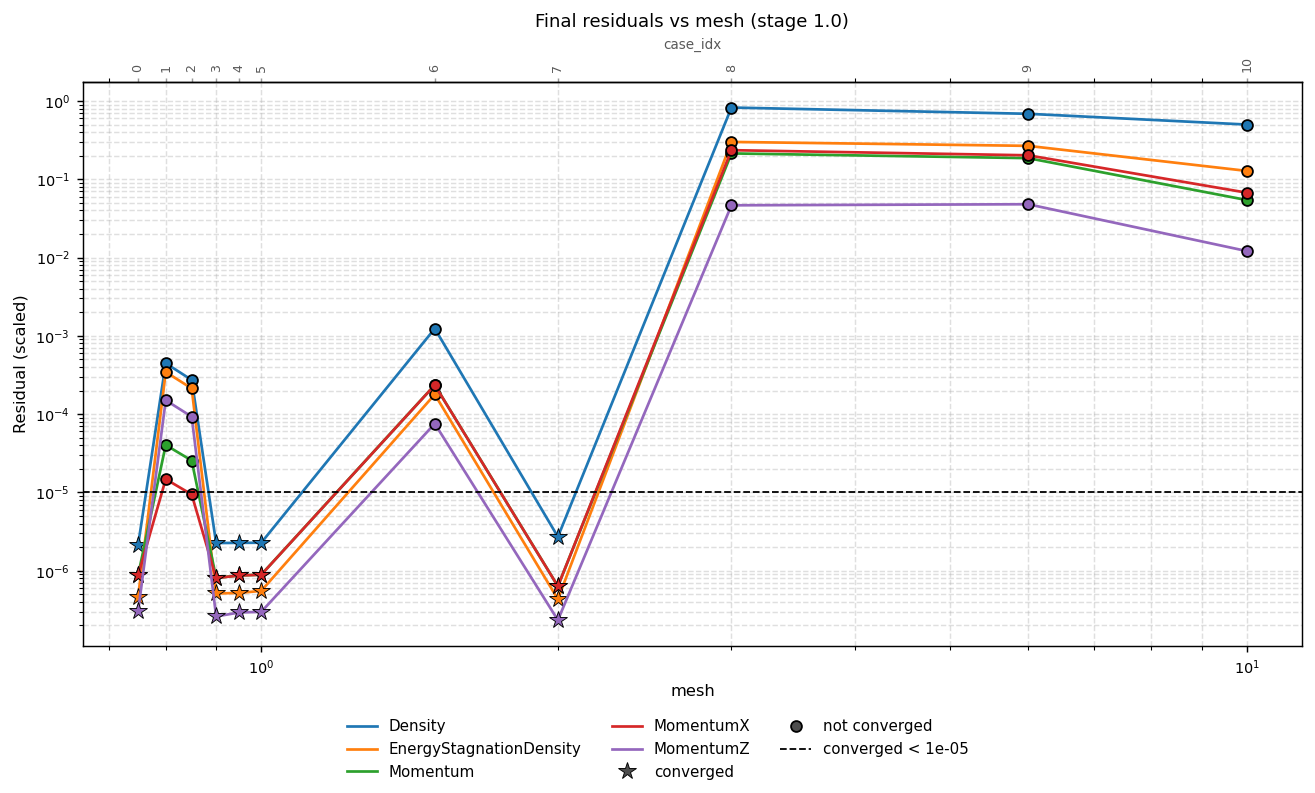
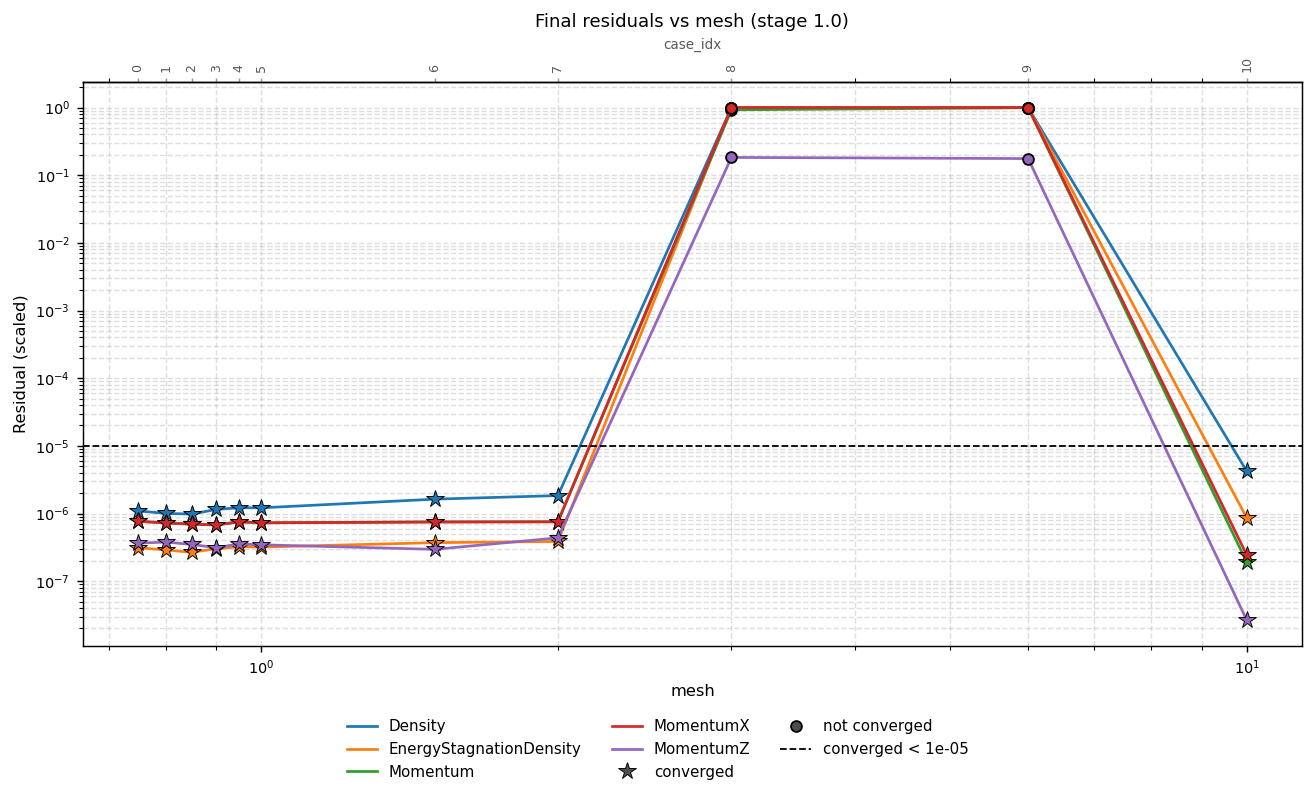
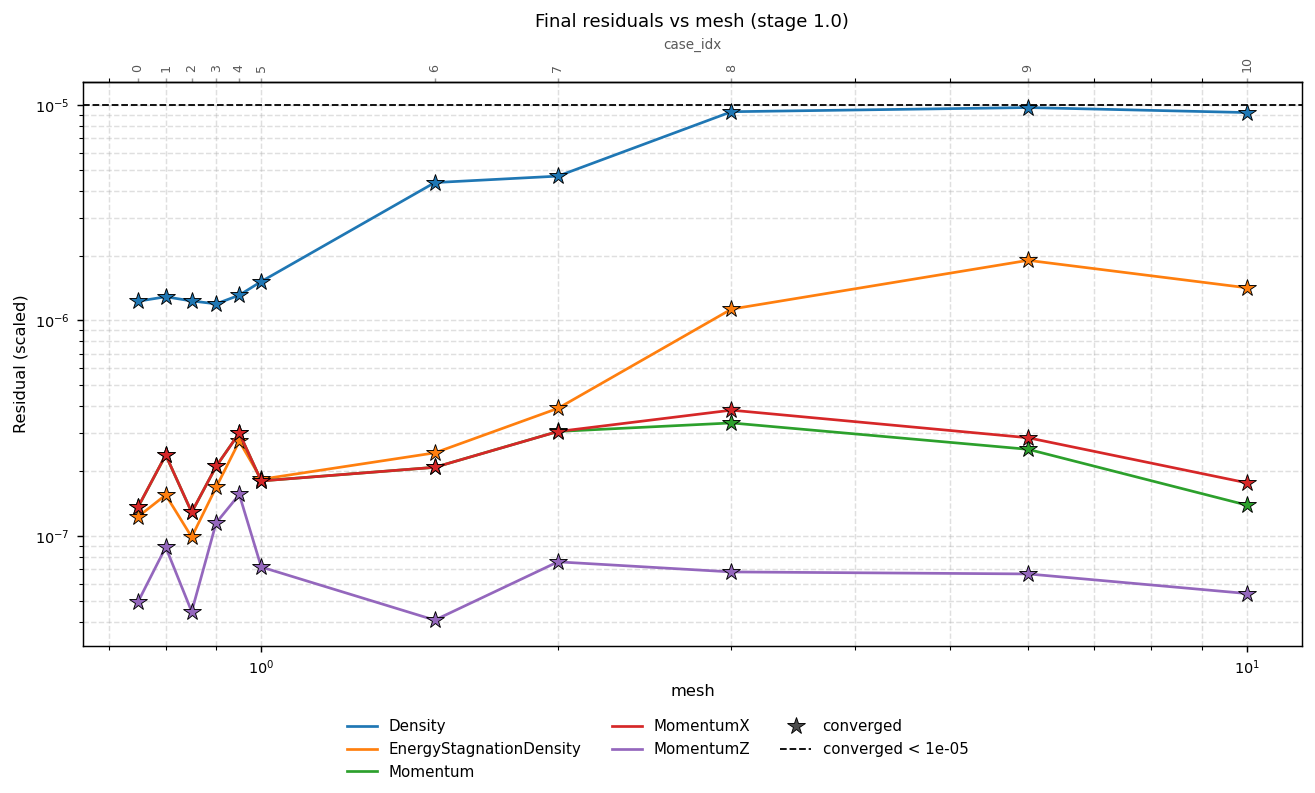

In [5]:
cols = [capture(db.residuals.plot_all_final_residuals,
                save_dir=None, mode='scaled', stage=[0, 1],
                only_finished=False, print_non_converged=False,
                activate_idx=True)
        for db in databases.values()]
grid(cols, folders, caption=T['c_residuals'])

## 1.4 Wall integral monitors

Iteration history of the aerodynamic coefficients. Colour encodes refinement
**sequentially** and the legend names each mesh, which is what helps when the case name
is itself a physical quantity.


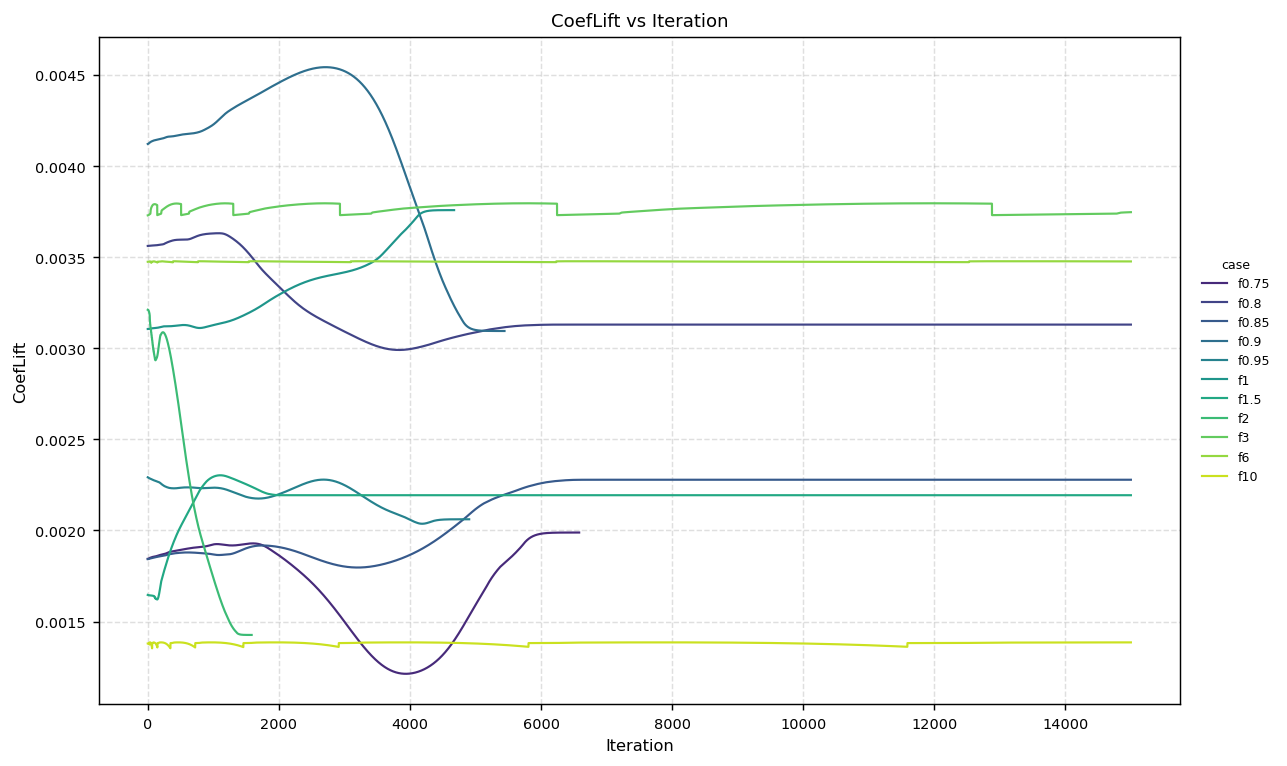
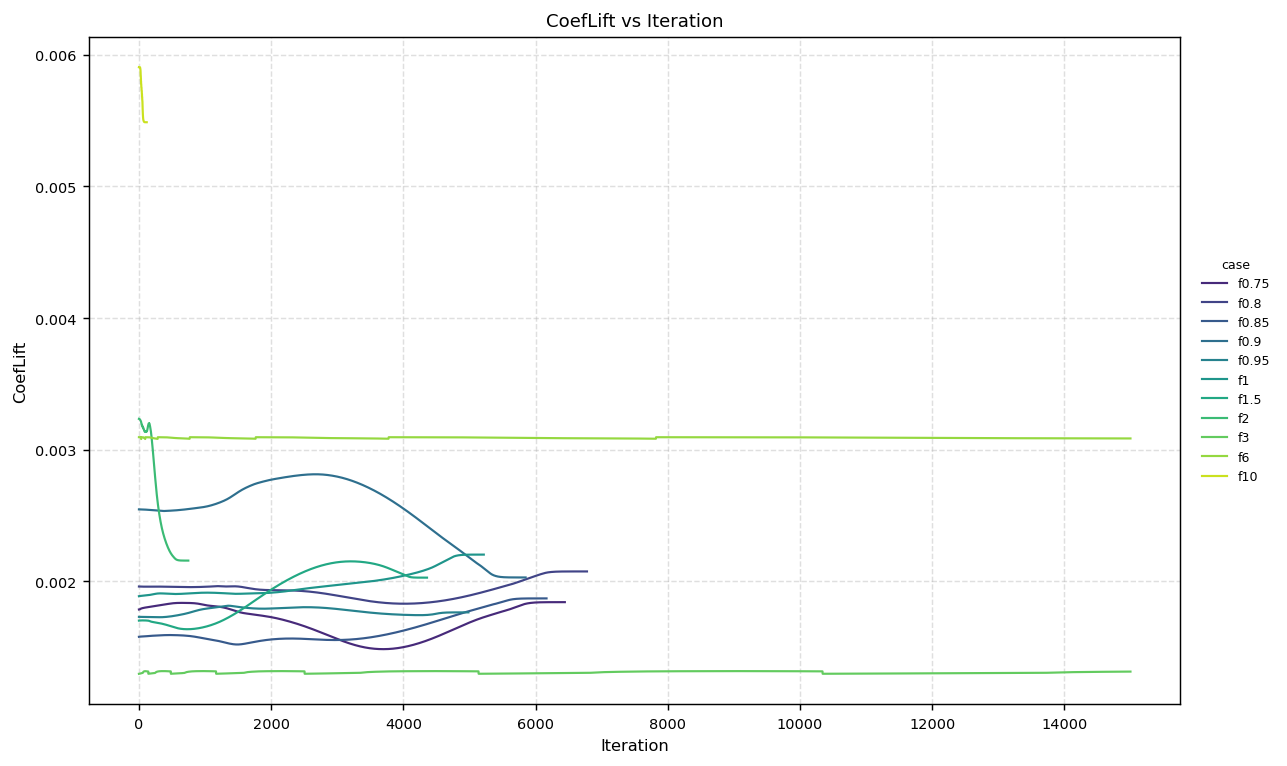
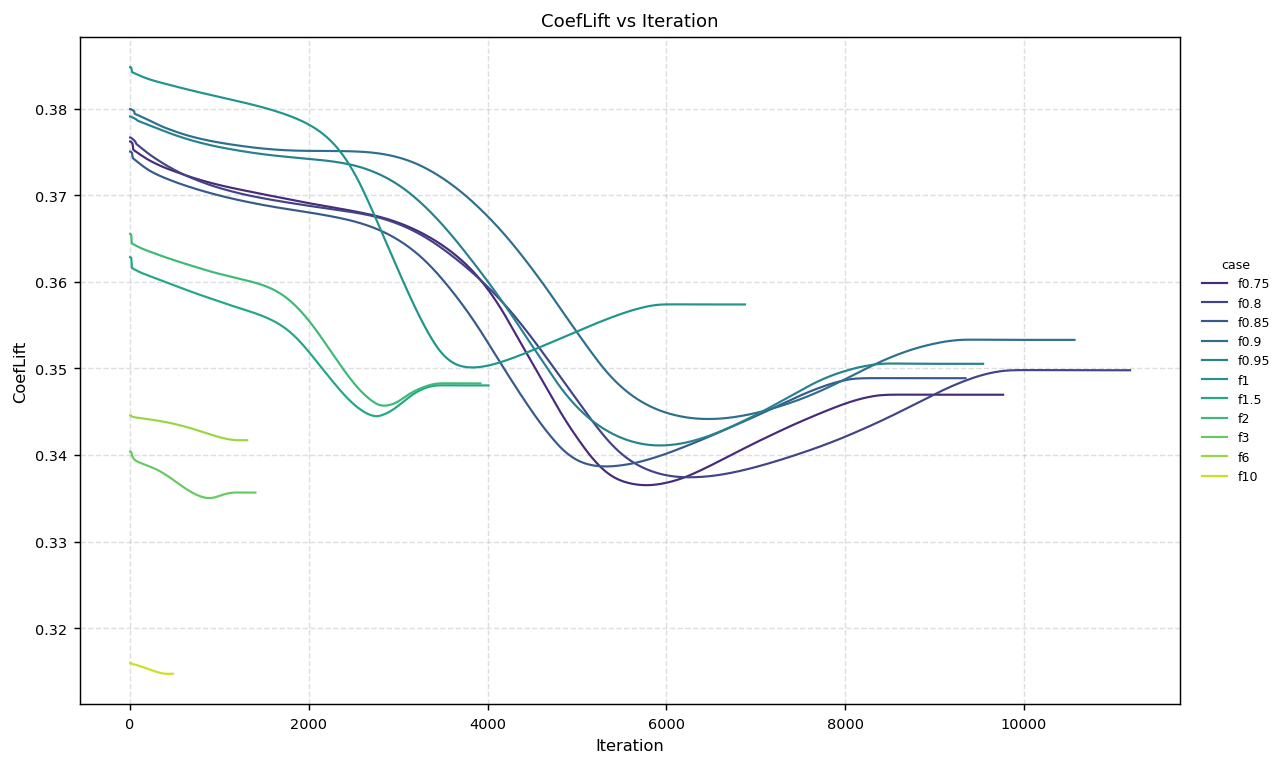
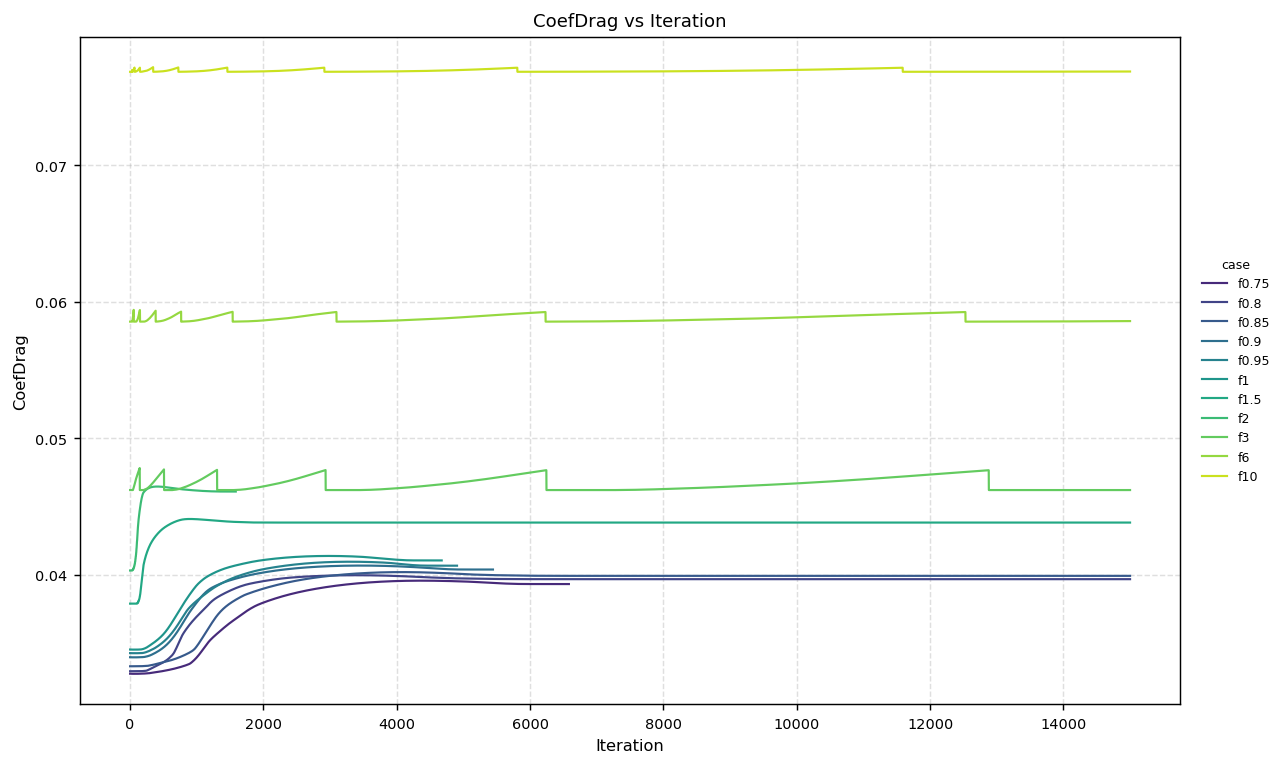
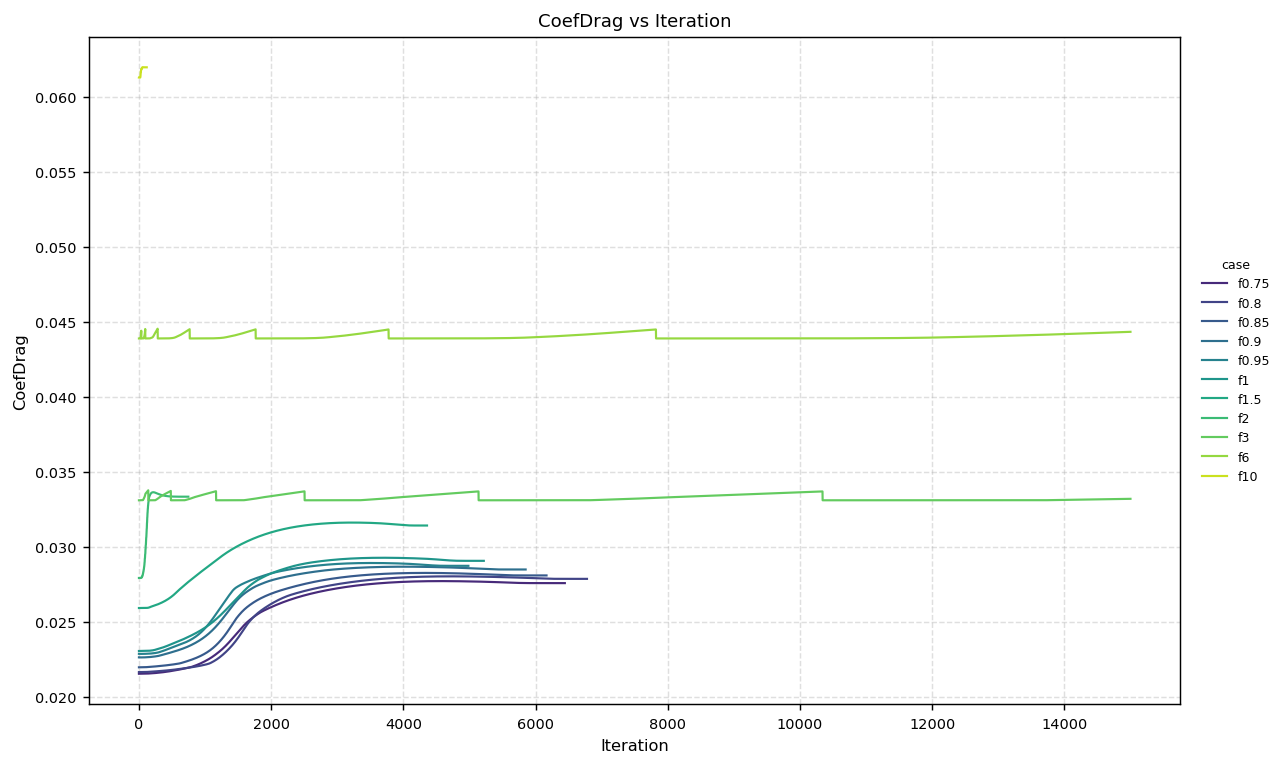
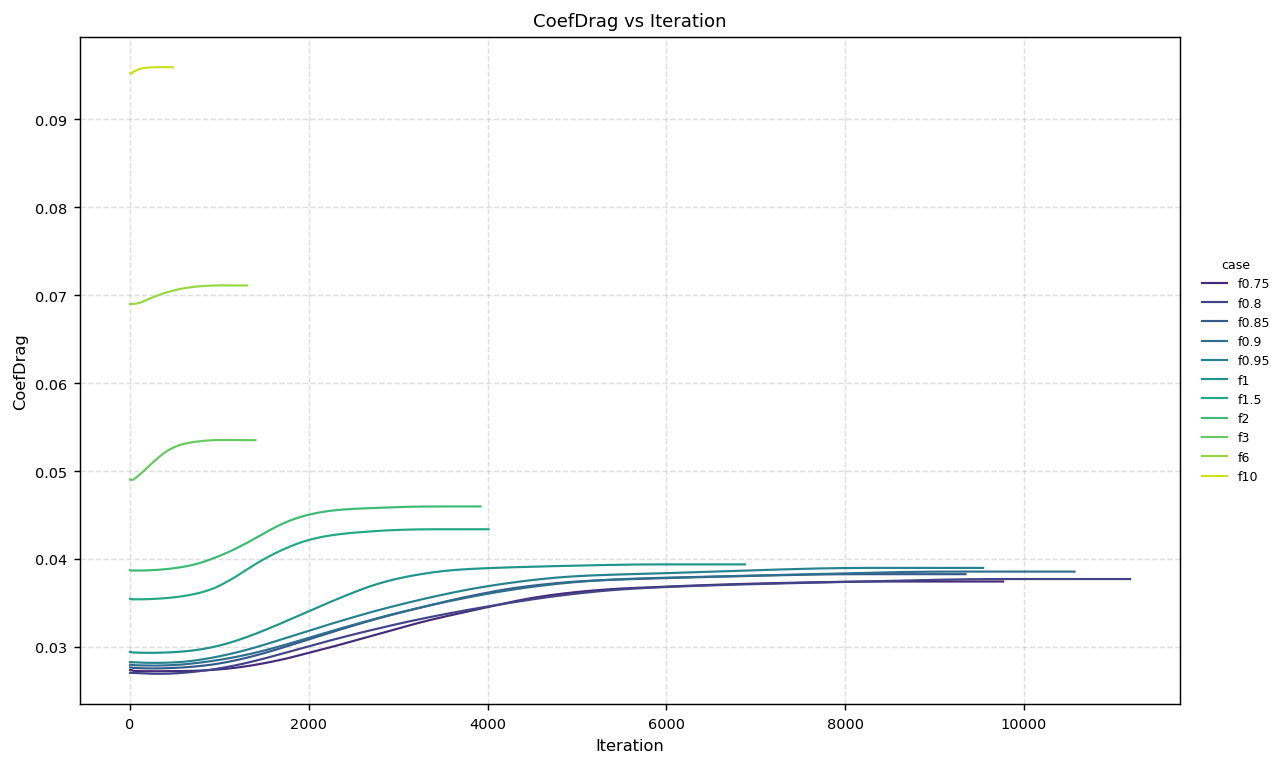
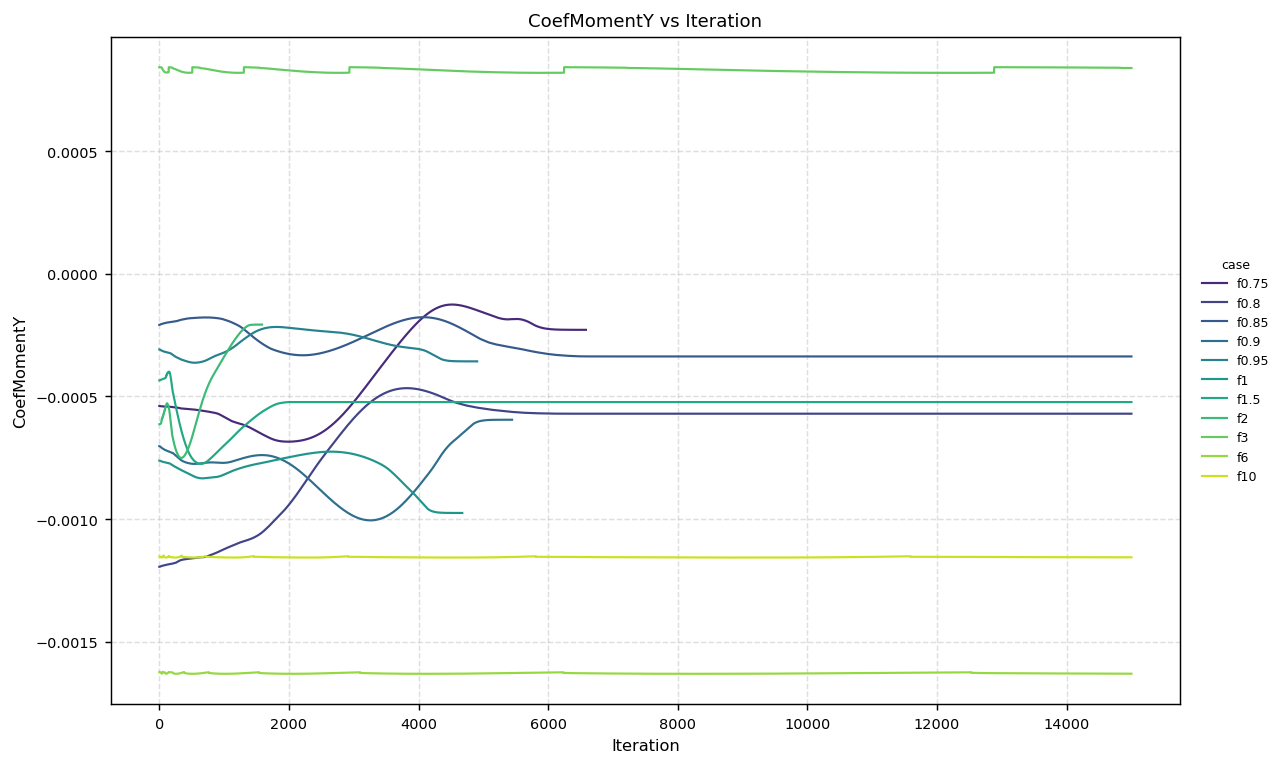
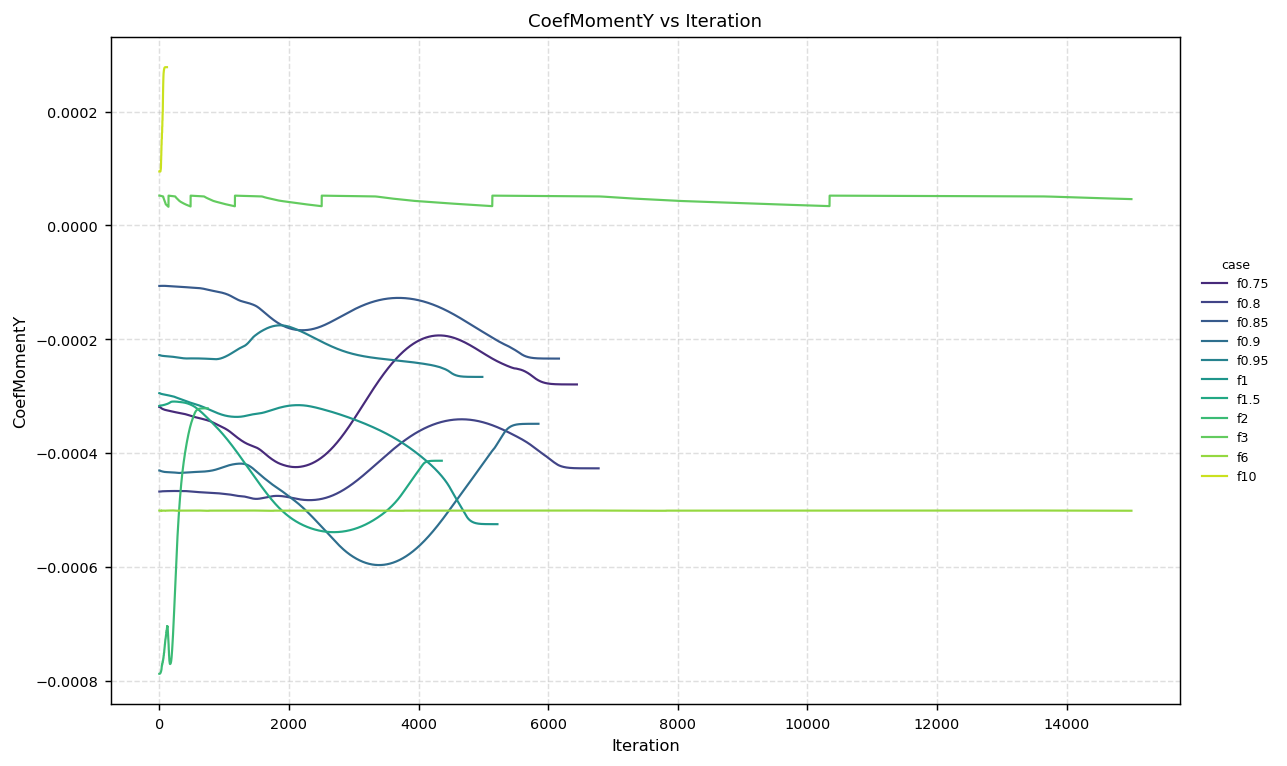
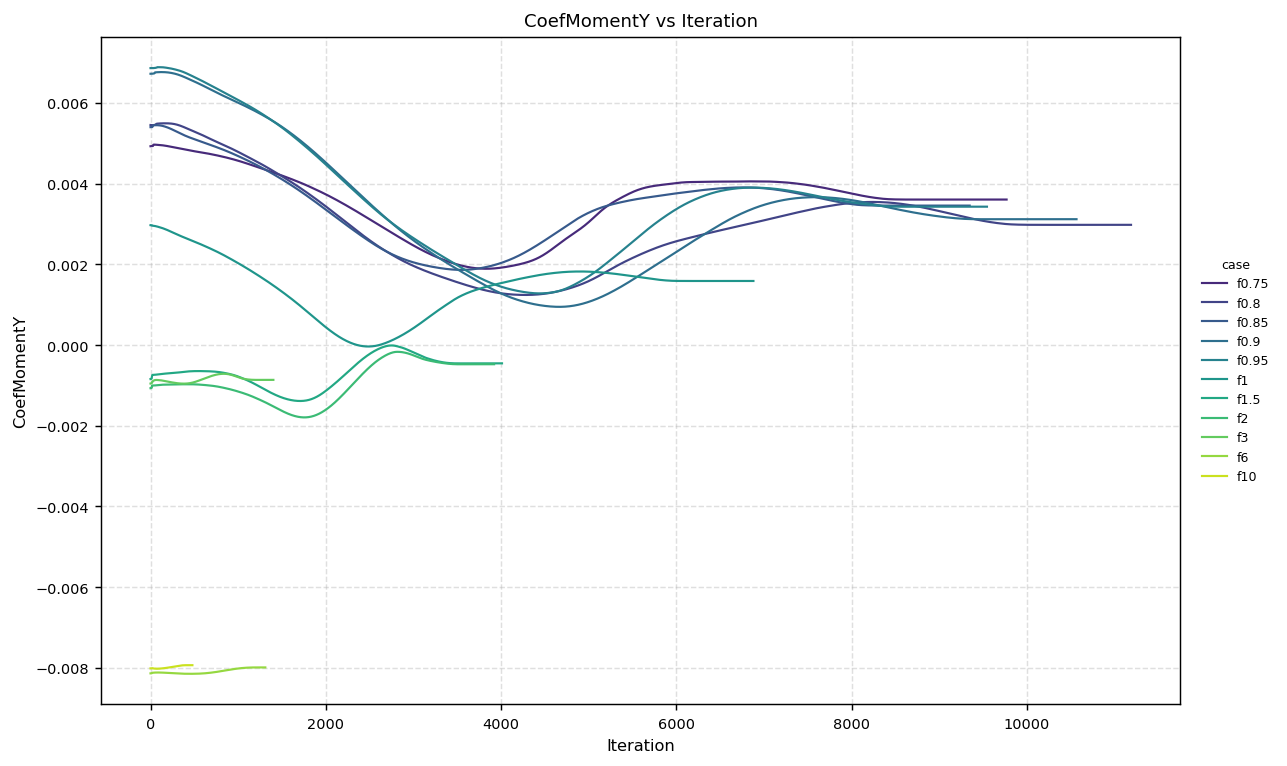

In [6]:
cols = [capture(db.sets.plot_wall_integrals,
                cases_idx=by_factor(db.metadata['df_cases'])['case_idx'].tolist(),
                stage=[STAGE], var_metrics=VARS, band=False,
                case_key='legend')
        for db in databases.values()]
grid(cols, folders, caption=T['c_monitors'].format(stage=STAGE))

---

# 2. Mesh family and surface extraction

In `CODA_SINGLE` every case keeps **its own geometry**: `Coord`, `Conec` and the fields
are lists aligned with the case order, not matrices sharing a point axis. That is the
structural difference from the `CODA` format, and the reason meshes cannot be compared
point by point — any comparison has to go through a reduction to a scalar first.

The three databases share exactly the same mesh family; only the flight condition
solved on them differs.

In [7]:
for db in databases.values():
    db.extract_inputs(id_groups=(GROUP,), cases_idx='all', vtu_type='surface')
    db.extract_outputs(stage=STAGE, id_groups=(GROUP,), cases_idx='all',
                       vtu_type='surface',
                       var_name_excluded=['GlobalNumber', 'CADGroupID'])

read = []
for f, db in databases.items():
    g = db.data_dict[f'CADGroup_{GROUP}']
    for i, case in enumerate(g['case_order']):
        read.append({T['db']: f, T['case']: case, 'f': g['FlCc'][i, 2],
                     T['cells']: g['Coord'][i].shape[0],
                     T['nodes']: g['NodeCoord'][i].shape[0]})
read = pd.DataFrame(read)

pivot = (read.pivot_table(index='f', columns=T['db'], values=T['cells'])
         .reset_index())
pivot[T['theoretical']] = np.floor(
    N_AIRFOIL_REF / pivot['f'] ** N_AIRFOIL_EXP).astype(int)
pivot[T['deviation']] = pivot[folders[0]] - pivot[T['theoretical']]

wide_table(fmt(pivot, 6), T['t_cells'], caption=T['c_cells'])

database,f,aoa_0.022_m_1.071,aoa_0.022_m_1.386,aoa_3.303_m_0.541,theoretical ⌊6500/f^0.8⌋,deviation
,0.75,8181,8181,8181,8182,-1
,0.8,7769,7769,7769,7770,-1
,0.85,7401,7401,7401,7402,-1
,0.9,7070,7070,7070,7071,-1
,0.95,6499,6499,6499,6772,-273
,1,6499,6499,6499,6500,-1
,1.5,4698,4698,4698,4699,-1
,2,3732,3732,3732,3733,-1
,3,2698,2698,2698,2699,-1
,6,1549,1549,1549,1550,-1



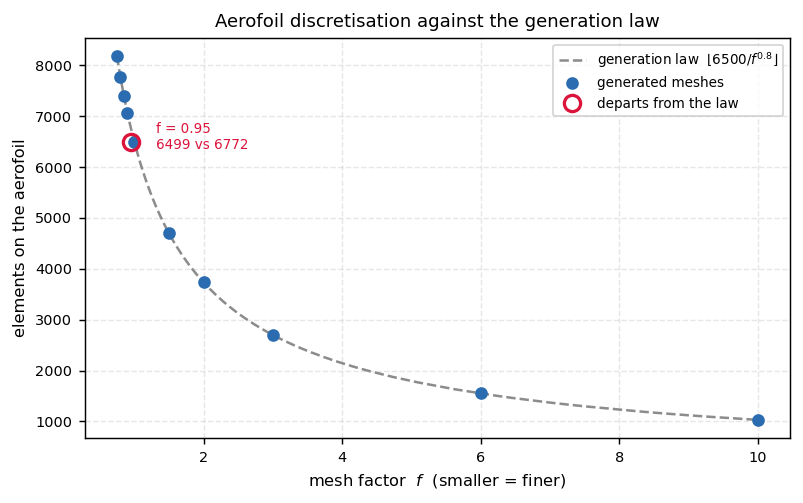

In [8]:
fig, ax = plt.subplots(figsize=(7.0, 4.0))
f_grid = np.linspace(read['f'].min(), read['f'].max(), 400)
ax.plot(f_grid, np.floor(N_AIRFOIL_REF / f_grid ** N_AIRFOIL_EXP),
        color='0.55', lw=1.4, ls='--',
        label=T['l_law'] + r'  $\lfloor 6500/f^{0.8}\rfloor$')

one = by_factor(read[read[T['db']] == folders[0]], 'f')
theo = np.floor(N_AIRFOIL_REF / one['f'] ** N_AIRFOIL_EXP)
off = (one[T['cells']] - theo).abs() > 2
ax.plot(one['f'][~off], one[T['cells']][~off], 'o', color='#2b6cb0',
        markersize=6, label=T['l_generated'])
ax.plot(one['f'][off], one[T['cells']][off], 'o', color='crimson',
        markersize=9, markerfacecolor='none', markeredgewidth=1.8,
        label=T['l_offlaw'])
for _, row in one[off].iterrows():
    ax.annotate(f"f = {row['f']:g}\n{int(row[T['cells']])} vs "
                f"{int(np.floor(N_AIRFOIL_REF / row['f']**N_AIRFOIL_EXP))}",
                (row['f'], row[T['cells']]), textcoords='offset points',
                xytext=(14, -4), fontsize=7.5, color='crimson')
ax.set(xlabel=T['x_factor'], ylabel=T['y_elements'])
ax.set_title(T['fig_law'])
ax.legend()
solo(as_png(fig), caption=T['c_law'])

> **Anomaly in the mesh family.** One mesh does not follow the generation law: it
> discretises the aerofoil with the same element count as the next coarser mesh, even
> though **its volume mesh is refined** (the `.msh` file has the intermediate size it
> should, and the solution it produces differs).
>
> The consequence is that for that mesh **$f$ no longer describes its wall resolution**.
> The study attributes to it a refinement step of $r \approx 1.05$ that did not happen
> on the surface, and that fictitious ratio goes straight into the $r^{\,p}-1$
> denominator of Richardson. The effect is severe for wall quantities (§3 and §6) and
> milder for the integral coefficients (§4), which do see the refined volume.
>
> It is excluded from every convergence computation that follows, and regenerating it
> would recover a refinement level currently lost.

---

# 3. Field statistics per mesh

The pressure coefficient $C_p$ is reduced to one scalar per mesh. That reduction is the
only thing comparable across meshes that share no points, and it is the input to the
field-based GCI of §6.

In [9]:
CP = 'BoundaryValues_CoefPressure'

stats_tables = []
for f, db in databases.items():
    t = db.stats.compute_stats(id_group=str(GROUP), stage=STAGE, variables=[CP],
                               reductions=('mean', 'rms', 'min', 'max', 'std'))
    t = by_factor(t)[['case', 'mesh', 'n_points', f'{CP}_mean', f'{CP}_rms',
                      f'{CP}_min', f'{CP}_max', f'{CP}_std']]
    t.columns = T['cols_stats']
    stats_tables.append(fmt(t, 4))

tables(stats_tables, folders, cols=3, caption=T['c_stats'])

case,f,cells,mean,RMS,min,max,std
f0.75,0.75,8181,-0.02164,0.2044,-0.3051,1.797,0.2033
f0.8,0.8,7769,-0.0217,0.2048,-0.2924,2.217,0.2037
f0.85,0.85,7401,-0.02118,0.2044,-0.295,2,0.2033
f0.9,0.9,7070,-0.02086,0.2044,-0.275,1.322,0.2033
f0.95,0.95,6499,-0.02128,0.2043,-0.3146,1.292,0.2032
f1,1,6499,-0.02144,0.2046,-0.3314,1.299,0.2034
f1.5,1.5,4698,-0.01989,0.2073,-0.3347,2.291,0.2063
f2,2,3732,-0.01986,0.209,-0.3759,2.473,0.2081
f3,3,2698,-0.02462,0.2087,-0.2918,1.276,0.2073
f6,6,1549,-0.02006,0.2113,-0.3935,1.171,0.2103


## 3.1 $C_p$ distribution per mesh

The scalar in the table above summarises a full distribution. The box plot shows all of
it: if box and whiskers settle as the mesh is refined, the field is converging; if they
keep moving, the mesh still dominates the result.


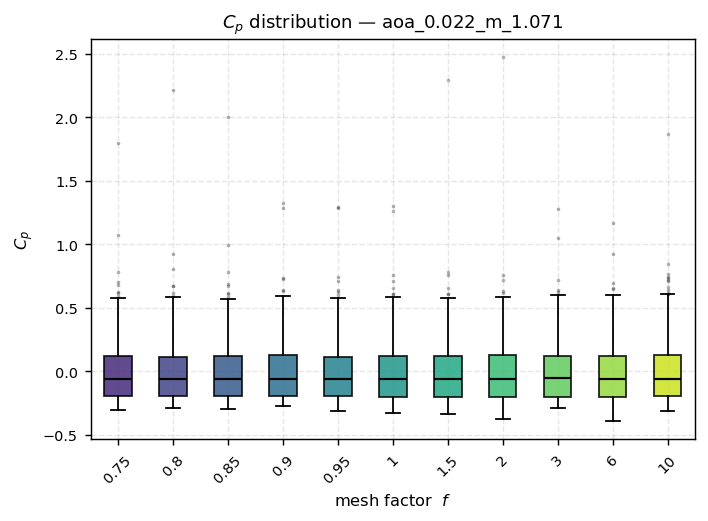
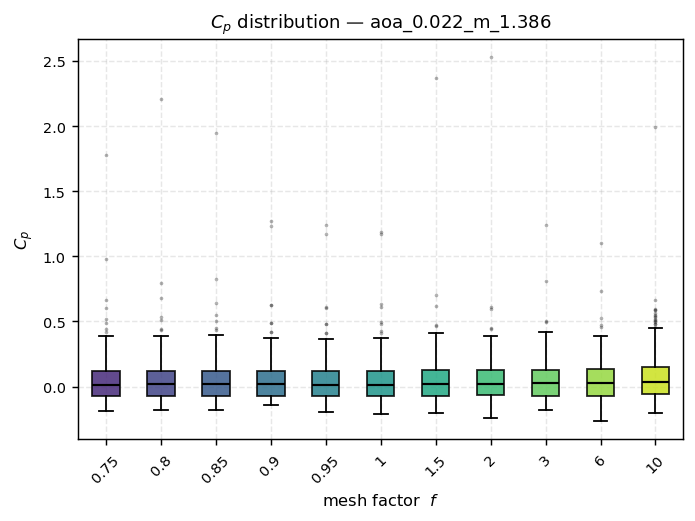
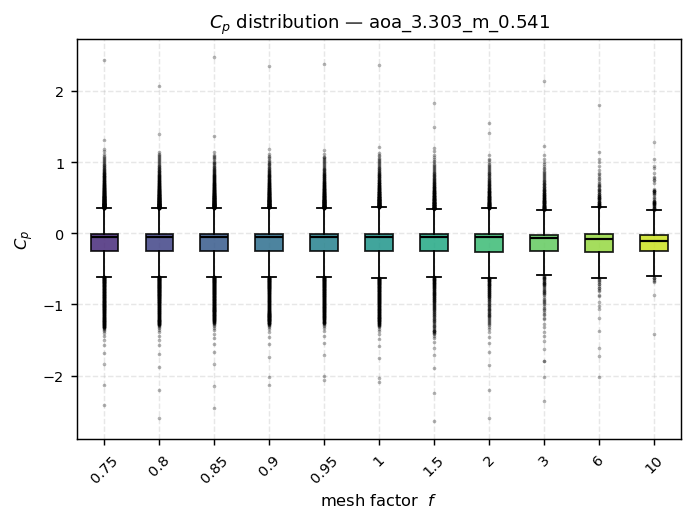

In [10]:
cols = []
for f, db in databases.items():
    g = db.data_dict[f'CADGroup_{GROUP}']
    order = np.argsort(g['FlCc'][:, 2])
    values = [np.asarray(g['Vars'][str(STAGE)][CP][i]).ravel() for i in order]
    labels = [f"{g['FlCc'][i, 2]:g}" for i in order]
    cmap = plt.get_cmap('viridis')
    shades = [cmap(0.12 + 0.80 * k / max(len(values) - 1, 1))
              for k in range(len(values))]

    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    bp = ax.boxplot(values, tick_labels=labels, patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, shade in zip(bp['boxes'], shades):
        patch.set_facecolor(shade)
        patch.set_alpha(0.85)
    ax.set(xlabel=T['x_factor_short'], ylabel='$C_p$')
    ax.set_title(f"{T['fig_cp']} — {f}")
    ax.tick_params(axis='x', rotation=45)
    cols.append([as_png(fig)])

grid(cols, folders, caption=T['c_cp_box'])

---

# 4. GCI on the integral coefficients

The classic target of a convergence study: one integral quantity per mesh, taken from
the solver's own monitors. This section is where the study stops describing and starts
deciding — it ends with a single recommended mesh.

In [11]:
post = {f: by_factor(
            db.residuals.get_df_metrics(var_metrics=VARS, iter_var=1000,
                                        save=False)
              .rename(columns={'folder': 'case'}))
        for f, db in databases.items()}

value_tables = []
for f in folders:
    t = post[f][['case', 'mesh'] + [f'{v}_mean_stage{STAGE}' for v in VARS]]
    t.columns = [T['case'], 'f'] + VARS
    value_tables.append(fmt(t, 5))

tables(value_tables, folders, cols=3,
       caption=T['c_values'].format(stage=STAGE))

case,f,CoefLift,CoefDrag,CoefMomentY
f0.75,0.75,0.0019669,0.039322,-0.00021913
f0.8,0.8,0.0031299,0.039673,-0.00057038
f0.85,0.85,0.0022783,0.039916,-0.00033684
f0.9,0.9,0.0031643,0.040403,-0.00062186
f0.95,0.95,0.0020549,0.040704,-0.00033975
f1,1,0.0037024,0.041088,-0.00093572
f1.5,1.5,0.0021934,0.04382,-0.00052295
f2,2,0.0017215,0.046171,-0.00032687
f3,3,0.0037384,0.046198,0.00084134
f6,6,0.003477,0.058565,-0.0016306


## 4.1 Converged simulations only

Before comparing meshes one has to be sure of comparing **solutions of the equations**
rather than wherever each run happened to stop. With a final residual of order
$10^{-1}$, the iterative error of a simulation exceeds the inter-mesh difference
Richardson is trying to measure, and the extrapolation amplifies that noise.

The criterion is the one FotR already applies elsewhere in the library
(`CODAResiduals.update_converged_state`): every normalised residual $r/r_0$ below
1e-04 at the end of the run.

> **`MomentumY` is left out of the criterion.** Its residual sits at ~0.8 on **every**
> mesh, including those reaching $10^{-6}$ in all other equations — the spanwise
> momentum equation is degenerate in this configuration. Requiring it to converge would
> flag the entire database as unconverged.

In [12]:
conv_tables = []
converged = {}
for f, db in databases.items():
    flags = converged_meshes(db)
    resid = final_residual_table(db)
    t = flags.merge(resid, on='mesh', how='left')
    t[T['converged']] = t['Converged'].astype(bool)
    t[T['excluded']] = t['folder'].isin(EXCLUDED_CASES)
    t = by_factor(t)[['folder', 'mesh', T['iterations'],
                      T['max_residual'], T['converged'], T['excluded']]]
    t.columns = [T['case'], 'f', T['iterations'], T['max_residual'],
                 T['converged'], T['excluded']]
    conv_tables.append(fmt(t, 3))
    converged[f] = set(t.loc[t[T['converged']] & ~t[T['excluded']], T['case']])

tables(conv_tables, folders, cols=3,
       caption=T['c_conv'].format(thr=f'{CONV_THRESHOLD:.0e}'))

case,f,iterations,max residual (r/r0),converged,excluded (§2)
f0.75,0.75,7222,9.9e-06,True,False
f0.8,0.8,15615,0.00223,False,False
f0.85,0.85,15606,0.00138,False,False
f0.9,0.9,6009,9.92e-06,True,False
f0.95,0.95,5455,9.91e-06,True,True
f1,1,5228,9.97e-06,True,False
f1.5,1.5,15508,0.00469,False,False
f2,2,2056,9.83e-06,True,False
f3,3,15422,1.05,False,False
f6,6,15317,1.29,False,False


In [13]:
sweep = []
for thr in CONV_SWEEP:
    row = {T['threshold']: f'{thr:.0e}'}
    sets = []
    for f, db in databases.items():
        flags = converged_meshes(db, threshold=thr)
        keep = set(flags.loc[flags['Converged'].astype(bool), 'folder'])
        keep -= set(EXCLUDED_CASES)
        sets.append(keep)
        row[f] = len(keep)
    common = set.intersection(*sets) if sets else set()
    row[T['common']] = len(common)
    row[T['triplets']] = (len(common) * (len(common) - 1)
                          * (len(common) - 2)) // 6
    sweep.append(row)

# restore the working threshold, the sweep left the last one in place
for db in databases.values():
    converged_meshes(db)

wide_table(pd.DataFrame(sweep), T['t_sweep'], caption=T['c_sweep'])

threshold,aoa_0.022_m_1.071,aoa_0.022_m_1.386,aoa_3.303_m_0.541,common,triplets
1e-06,0,0,0,0,0
1e-05,4,8,10,4,4
1e-04,4,8,10,4,4
1e-03,4,8,10,4,4
5e-03,7,8,10,7,35


That filter is what decides the study, and it is worth seeing why: one of the three
flight conditions is left with very few meshes, and it is the one that ends up
constraining everything else.

## 4.2 Every admissible triplet, scored

A GCI triplet need not be built from **adjacent** meshes. All Richardson requires is
three distinct, ordered sizes; quality is set by the refinement ratio, not by adjacency.
Restricting the study to windows of three neighbours is exactly what would guarantee
refinement steps of 5 % here. So **every combination of three converged meshes** is
enumerated, $\binom{n}{3}$ per flight condition.

### Rejected versus penalised

A triplet is **rejected** — it does not appear at all — only when the extrapolation is
inapplicable:

- one of the three meshes did not converge, or is `f0.95`;
- the observed order does not resolve: null differences, or oscillatory convergence;
- $r_{21} \leq 1$ or $r_{32} \leq 1$, which is not a refinement.

Everything else is **penalised** through a score rather than silently removed. That
choice matters: a hard plausibility band on $p$ would hide candidates instead of ranking
them, and the edge of such a band is always arbitrary.

### The score

Five terms in $[0,1]$, higher is better:

| term | measures | weight |
|---|---|---|
| $1/(1+\lvert AR-1\rvert)$ | asymptotic ratio near 1 — the hypothesis the extrapolation rests on | 0.35 |
| $1/(1+\lvert p-2\rvert/2)$ | observed order near the nominal second order of the scheme | 0.25 |
| $\mathrm{clip}(\min(r_{21},r_{32})-1,\,0,\,1)$ | refinement above the iterative noise, saturating at $r=2$ | 0.20 |
| $\min(r)/\max(r)$ | balanced steps, as Roache recommends | 0.10 |
| normalised, inverted $h_1$ | the fine mesh, where the reported value lives | 0.10 |

> **The GCI is deliberately not a term.** Ranking by the GCI selects the smallest
> estimate; across a hundred candidates that is fishing, not measuring. The order term
> is what handles the $p \approx 10$ triplets: it sinks them to the bottom of the
> ranking without a filter to hide them.

The weights live in `SCORE_WEIGHTS` and are open to argument; what should not change is
the exclusion of the GCI itself.

In [14]:
decision_col = f'{DECISION_VAR}_mean_stage{STAGE}'

ranked, admissible = {}, {}
for f, db in databases.items():
    family = post[f][post[f]['case'].isin(converged[f])]
    raw = db.stats.richardson(family.dropna(subset=[decision_col]),
                              decision_col, h_col='mesh', triplets='all')
    raw['trio'] = raw['fine'] + ' / ' + raw['medium'] + ' / ' + raw['coarse']
    raw['GCI_%'] = raw['GCI_21'] * 100
    admissible[f] = raw
    ok = raw[raw['converged'] & (raw['r21'] > 1) & (raw['r32'] > 1)
             & np.isfinite(raw['asymptotic_ratio'])]
    ranked[f] = score_triplets(ok)

overview = pd.DataFrame([{
    T['db']: f,
    T['n_converged']: len(converged[f]),
    T['n_combinations']: len(admissible[f]),
    T['n_admissible']: len(ranked[f]),
    T['n_p_band'] % (P_MIN, P_MAX):
        int(ranked[f]['p'].between(P_MIN, P_MAX).sum()),
} for f in folders])

wide_table(overview, T['t_counts'],
           caption=T['c_counts'].format(var=DECISION_VAR))

database,converged meshes,combinations,admissible triplets,"with p in [0.5, 4.0]"
aoa_0.022_m_1.071,4,4,2,1
aoa_0.022_m_1.386,8,56,21,13
aoa_3.303_m_0.541,10,120,61,51


In [15]:
per_root = []
for f in folders:
    t = ranked[f][['rank', 'trio', 'r21', 'r32', 'p', 'asymptotic_ratio',
                   'GCI_%', 'S_asym', 'S_order', 'S_refine', 'S_balance',
                   'S_fine', 'score']].copy()
    t.columns = T['cols_ranked']
    per_root.append(fmt(t, 4))

tables(per_root, folders, cols=1, caption=T['c_ranked'])

rank,triplet (fine / medium / coarse),r21,r32,p,asympt. ratio,GCI [%],asympt.,order,refin.,balance,fineness,SCORE
1,f0.75 / f1 / f2,1.333,2,0.3587,0.957,51.63,0.9588,0.5493,0.3333,0.6667,1,0.7062
2,f0.75 / f0.9 / f1,1.2,1.111,0.6458,0.9733,27.49,0.974,0.5963,0.1111,0.9259,1,0.7048
rank,triplet (fine / medium / coarse),r21,r32,p,asympt. ratio,GCI [%],asympt.,order,refin.,balance,fineness,SCORE
1,f0.75 / f2 / f10,2.667,5,0.931,0.846,15.25,0.8665,0.6517,1,0.5333,1,0.8195
2,f0.75 / f0.8 / f0.9,1.067,1.125,2.041,0.9896,9.321,0.9897,0.9799,0.06667,0.9481,1,0.7995
3,f0.8 / f2 / f10,2.5,5,0.9432,0.8549,15.45,0.8733,0.6543,1,0.5,0.8,0.7992
4,f0.85 / f2 / f10,2.353,5,0.9478,0.862,16.01,0.8787,0.6553,1,0.4706,0.6,0.7784
5,f0.9 / f2 / f10,2.222,5,0.9841,0.8744,15.03,0.8884,0.6631,1,0.4444,0.4,0.7612
6,f0.75 / f0.85 / f1,1.133,1.176,2.713,0.9815,5.836,0.9818,0.7371,0.1333,0.9633,1,0.7509
7,f0.75 / f1 / f1.5,1.333,1.5,0.3033,0.9477,75.7,0.9503,0.541,0.3333,0.8889,1,0.7234


### What the filter changes, and what it does not

The plot below compares the GCI distribution **before and after** the convergence
filter, over the same flight conditions. It is worth reading without assuming the
answer.


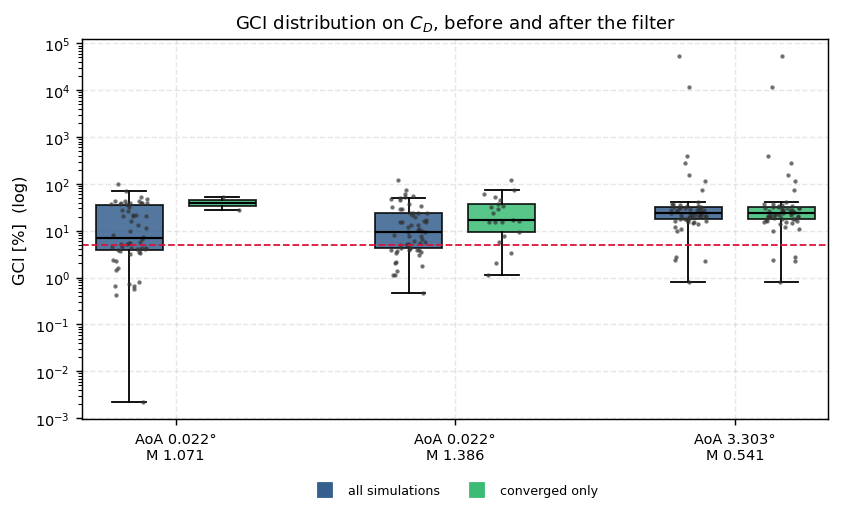

In [16]:
fig, ax = plt.subplots(figsize=(7.4, 3.8))
shades = plt.get_cmap('viridis')([0.30, 0.68])
ticks, labels = [], []
for fi, f in enumerate(folders):
    db = databases[f]
    raw_all = db.stats.richardson(
        post[f][~post[f]['case'].isin(EXCLUDED_CASES)]
        .dropna(subset=[decision_col]),
        decision_col, h_col='mesh', triplets='all')
    before = raw_all.loc[raw_all['converged'] & (raw_all['GCI_21'] > 0),
                         'GCI_21'] * 100
    after = ranked[f].loc[ranked[f]['GCI_%'] > 0, 'GCI_%']
    for k, (data, shade) in enumerate(zip((before, after), shades)):
        pos = fi * 3 + k
        if len(data):
            bp = ax.boxplot([data.to_numpy()], positions=[pos], widths=0.72,
                            patch_artist=True, showfliers=False,
                            medianprops=dict(color='black', lw=1.2))
            bp['boxes'][0].set_facecolor(shade)
            bp['boxes'][0].set_alpha(0.85)
            ax.plot(np.full(len(data), pos)
                    + np.random.default_rng(1).uniform(-0.2, 0.2, len(data)),
                    data, '.', color='0.2', markersize=3, alpha=0.55)
    ticks.append(fi * 3 + 0.5)
    labels.append(f.replace('aoa_', 'AoA ').replace('_m_', '°\nM '))

ax.set(yscale='log', ylabel='GCI [%]  (log)')
ax.set_xticks(ticks)
ax.set_xticklabels(labels, fontsize=8)
ax.axhline(5, color='crimson', ls='--', lw=1.0)
ax.set_title(T['fig_filter'].format(var=NICE[DECISION_VAR]))
ax.legend(handles=[plt.Line2D([], [], marker='s', linestyle='none',
                              color=shades[0], markersize=8,
                              label=T['l_all_sims']),
                   plt.Line2D([], [], marker='s', linestyle='none',
                              color=shades[1], markersize=8,
                              label=T['l_conv_only'])],
          fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.14),
          ncols=2, frameon=False)
solo(as_png(fig), caption=T['c_filter'])

The outcome is not the expected one. **Filtering by convergence discards candidates
but does not explain the scatter.** In the condition where almost every simulation
converges, the distribution before and after is essentially the same: were iterative
noise the cause, there would be scatter to remove there. Where the distribution narrows
sharply it does so only because two or three candidates remain, not because they agree.

The conclusion is awkward but useful: **iterative error is not the main driver of the
scatter.** Almost certainly the driver is that the solutions are not in the asymptotic
range over this family — which the observed orders of §4.4 will confirm.

The filter stays, because a triplet built on a half-converged simulation is
indefensible however attractive its GCI. But it is worth knowing what it fixes and what
it does not.

## 4.3 Consensus across flight conditions

A mesh that is good at one flight point is of no use: the choice has to hold at all
three. The procedure is direct:

1. within each condition, rank the triplets by score;
2. take the **top $n$** of each and intersect;
3. increase $n$ until the intersection is non-empty. That $n^\*$ and those triplets are
   the candidates.

> This is not an arbitrary recipe: **the first triplet to enter the intersection is
> exactly the one whose worst rank across the three conditions is smallest.** The sweep
> is therefore a *minimax* selection — it picks the triplet whose behaviour at its least
> favourable condition is the best available. That is the right criterion when what is
> wanted is a mesh that does not fail at any flight point.


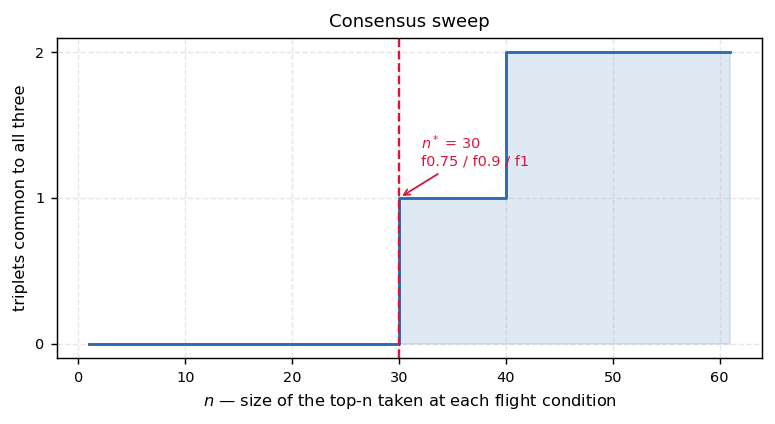

In [17]:
sweep_df, n_star, candidates = consensus_sweep(ranked)

fig, ax = plt.subplots(figsize=(7.0, 3.2))
ax.step(sweep_df['n'], sweep_df['common'], where='post', color='#2b6cb0',
        lw=1.6)
ax.fill_between(sweep_df['n'], sweep_df['common'], step='post',
                color='#2b6cb0', alpha=0.15)
if n_star is not None:
    ax.axvline(n_star, color='crimson', ls='--', lw=1.3)
    ax.annotate(f'$n^*$ = {n_star}\n{candidates[0]}',
                xy=(n_star, 1), xytext=(12, 18),
                textcoords='offset points', fontsize=8, color='crimson',
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.0))
ax.set(xlabel=T['x_topn'], ylabel=T['y_common'])
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title(T['fig_sweep'])
solo(as_png(fig), caption=T['c_sweep_fig'])

In [18]:
rows = []
for trio in candidates:
    row = {T['triplet']: trio}
    for f in folders:
        hit = ranked[f][ranked[f]['trio'] == trio].iloc[0]
        short = f.replace('aoa_', '').replace('_m_', ' / M')
        row[f"{T['rank']} {short}"] = int(hit['rank'])
        row[f"{T['score_abbr']} {short}"] = hit['score']
    ranks = [v for k, v in row.items() if k.startswith(T['rank'] + ' ')]
    scores = [v for k, v in row.items()
              if k.startswith(T['score_abbr'] + ' ')]
    row[T['worst_rank']] = max(ranks)
    row[T['worst_score']] = min(scores)
    rows.append(row)

winners = (pd.DataFrame(rows)
           .sort_values([T['worst_rank'], T['worst_score']],
                        ascending=[True, False])
           .reset_index(drop=True))
winner = winners[T['triplet']].iloc[0]

wide_table(fmt(winners, 4), T['t_candidates'].format(n=n_star),
           caption=T['c_candidates'])

triplet,rank 0.022 / M1.071,score 0.022 / M1.071,rank 0.022 / M1.386,score 0.022 / M1.386,rank 3.303 / M0.541,score 3.303 / M0.541,worst rank,worst score
f0.75 / f0.9 / f1,2,0.7048,8,0.7073,30,0.7673,30,0.7048


## 4.4 The winning triplet

In [19]:
rows = []
for f in folders:
    hit = ranked[f][ranked[f]['trio'] == winner].iloc[0]
    rows.append({
        T['db']: f,
        T['rank']: int(hit['rank']),
        'r21': hit['r21'], 'r32': hit['r32'],
        T['p_observed']: hit['p'],
        f"{DECISION_VAR} {T['on_fine']}": hit['f1'],
        T['extrapolated']: hit['f_extrapolated'],
        'GCI [%]': hit['GCI_%'],
        T['asym_ratio']: hit['asymptotic_ratio'],
        T['score_full']: hit['score'],
    })
detail = pd.DataFrame(rows)

wide_table(fmt(detail, 5), T['t_winner'].format(trio=winner),
           caption=T['c_winner'].format(var=DECISION_VAR))

database,rank,r21,r32,observed p,CoefDrag on fine mesh,extrapolated,GCI [%],asympt. ratio,score
aoa_0.022_m_1.071,2,1.2,1.1111,0.64577,0.039322,0.030674,27.491,0.97325,0.70476
aoa_0.022_m_1.386,8,1.2,1.1111,0.74288,0.027599,0.021203,28.97,0.96748,0.7073
aoa_3.303_m_0.541,30,1.2,1.1111,1.6459,0.037437,0.034223,10.732,0.97083,0.76729


### Cross-check against the other two coefficients

The decision rests on a single coefficient. It remains to see whether the winner also
behaves reasonably for the other two — bearing in mind that at low angle of attack
their relative GCI is meaningless, since the coefficient passes close to zero.

In [20]:
rows = []
for f in folders:
    db = databases[f]
    family = post[f][post[f]['case'].isin(converged[f])]
    row = {T['db']: f}
    for var in VARS:
        col = f'{var}_mean_stage{STAGE}'
        clean = family.dropna(subset=[col])
        if len(clean) < 3:
            row[f'p {PLAIN[var]}'] = np.nan
            row[f'GCI {PLAIN[var]} [%]'] = np.nan
            continue
        g = db.stats.richardson(clean, col, h_col='mesh', triplets='all')
        g['trio'] = g['fine'] + ' / ' + g['medium'] + ' / ' + g['coarse']
        hit = g[g['trio'] == winner]
        row[f'p {PLAIN[var]}'] = hit['p'].iloc[0] if len(hit) else np.nan
        row[f'GCI {PLAIN[var]} [%]'] = (hit['GCI_21'].iloc[0] * 100
                                        if len(hit) else np.nan)
    rows.append(row)

wide_table(fmt(pd.DataFrame(rows), 4),
           T['t_crosscheck'].format(trio=winner), caption=T['c_crosscheck'])

database,p CL,GCI CL [%],p CD,GCI CD [%],p CMy,GCI CMy [%]
aoa_0.022_m_1.071,1.134,331.2,0.6458,27.49,2.107,490.4
aoa_0.022_m_1.386,3.442,20.84,0.7429,28.97,4.592,37.26
aoa_3.303_m_0.541,0.7694,15.17,1.646,10.73,12.76,1.829


## 4.5 Recommended mesh

Of the winning triplet, the mesh delivered is **the fine one**: it is the only one whose
uncertainty the computed GCI bounds, since the Richardson band is built around its
value.

In [21]:
fine_mesh = winner.split(' / ')[0]

rows = []
for f in folders:
    db = databases[f]
    hit = ranked[f][ranked[f]['trio'] == winner].iloc[0]
    geo = db.data_dict[f'CADGroup_{GROUP}']
    pos = list(geo['case_order']).index(fine_mesh)
    band = abs(hit['f_extrapolated']) * hit['GCI_21']
    rows.append({
        T['db']: f,
        T['mesh']: fine_mesh,
        T['wall_cells']: int(np.shape(geo['Coord'][pos])[0]),
        f"{DECISION_VAR} {T['computed']}": hit['f1'],
        T['extrapolated_h0']: hit['f_extrapolated'],
        'GCI [%]': hit['GCI_%'],
        T['band']: band,
    })
recommended = pd.DataFrame(rows)

wide_table(fmt(recommended, 5), T['t_recommended'].format(mesh=fine_mesh),
           caption=T['c_recommended'].format(var=DECISION_VAR))

database,mesh,wall cells,CoefDrag computed,extrapolated (h→0),GCI [%],band ±
aoa_0.022_m_1.071,f0.75,8181,0.039322,0.030674,27.491,0.0084327
aoa_0.022_m_1.386,f0.75,8181,0.027599,0.021203,28.97,0.0061425
aoa_3.303_m_0.541,f0.75,8181,0.037437,0.034223,10.732,0.0036727



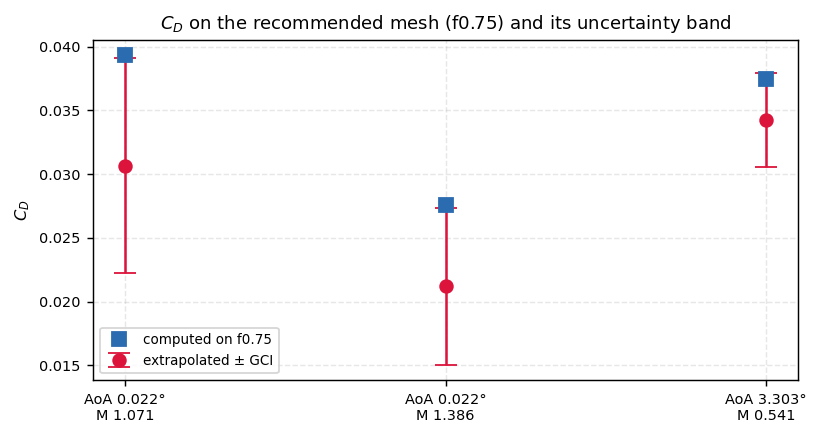

In [22]:
fig, ax = plt.subplots(figsize=(7.0, 3.4))
x = np.arange(len(folders))
values = recommended[f"{DECISION_VAR} {T['computed']}"].astype(float).to_numpy()
ext = recommended[T['extrapolated_h0']].astype(float).to_numpy()
band = recommended[T['band']].astype(float).to_numpy()

ax.errorbar(x, ext, yerr=band, fmt='o', color='crimson', markersize=7,
            capsize=6, lw=1.4, label=T['l_ext_band'], zorder=3)
ax.plot(x, values, 's', color='#2b6cb0', markersize=8, zorder=4,
        label=T['l_computed_on'].format(mesh=fine_mesh))
ax.set_xticks(x)
ax.set_xticklabels([f.replace('aoa_', 'AoA ').replace('_m_', '°\nM ')
                    for f in folders], fontsize=8)
ax.set_ylabel(NICE[DECISION_VAR])
ax.set_title(T['fig_recommended'].format(var=NICE[DECISION_VAR],
                                         mesh=fine_mesh))
ax.legend(fontsize=7.5, loc='best')
solo(as_png(fig), caption=T['c_recommended_fig'])

> **Caveat attached to the result.** The winner is the best of what is available, not
> good in absolute terms: its observed orders fall below the nominal second order of the
> scheme, and its GCI runs to several tens of per cent at two of the three conditions.
> The method delivers the best mesh these data support; **it does not demonstrate that
> the solution is mesh-converged.** §7 sets out what would be needed for that.

---

# 5. Convergence curves

Each coefficient against the mesh factor, over the **whole** family: nothing is filtered
here, because which simulation converged and which did not is part of the diagnosis.
Unconverged runs are drawn with an open marker.

Overlaid on them is the **winning triplet of §4.3** with its extrapolated value and GCI
band, computed on the decision variable.


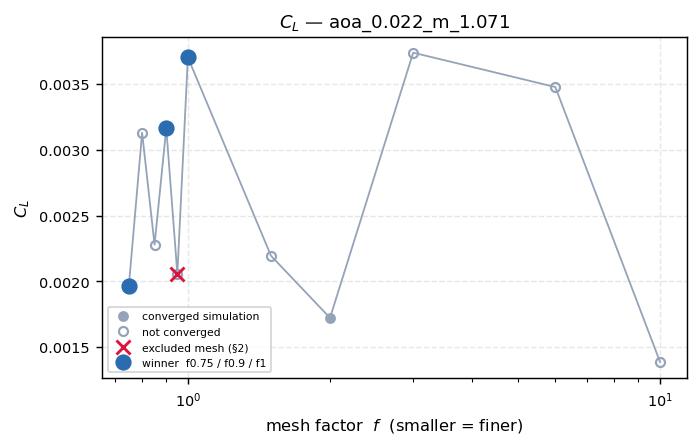
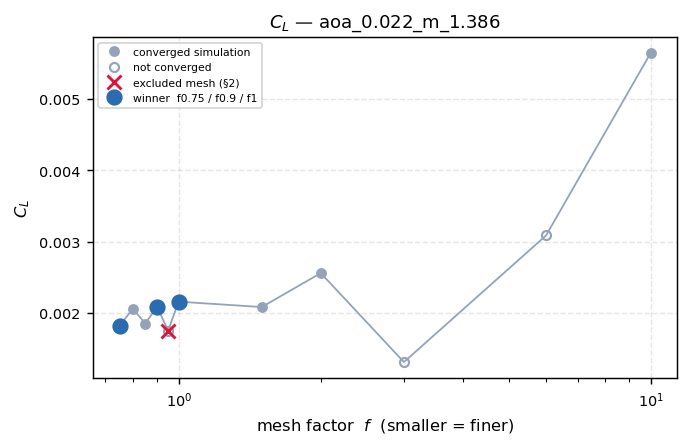
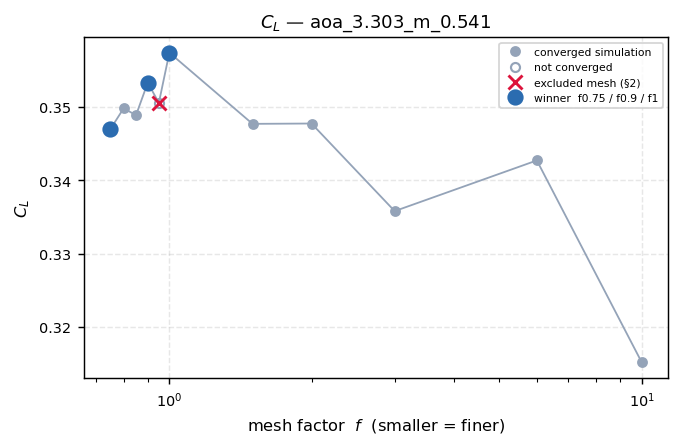
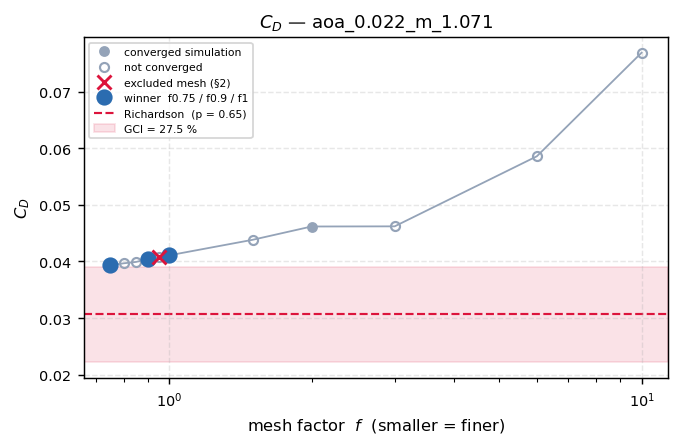
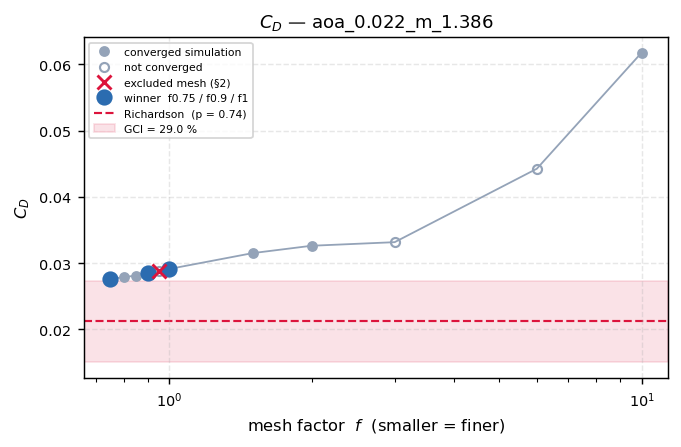
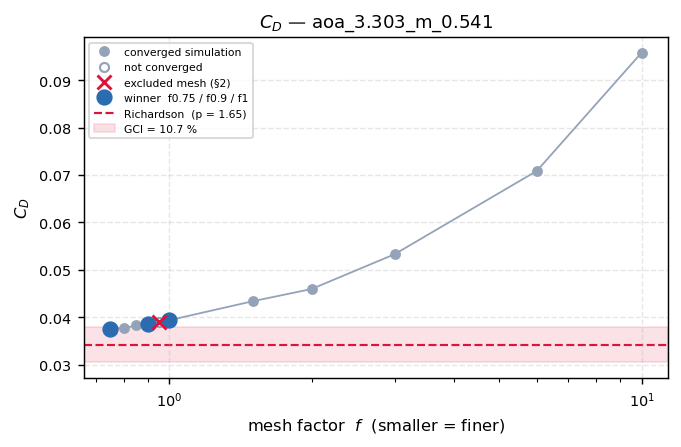
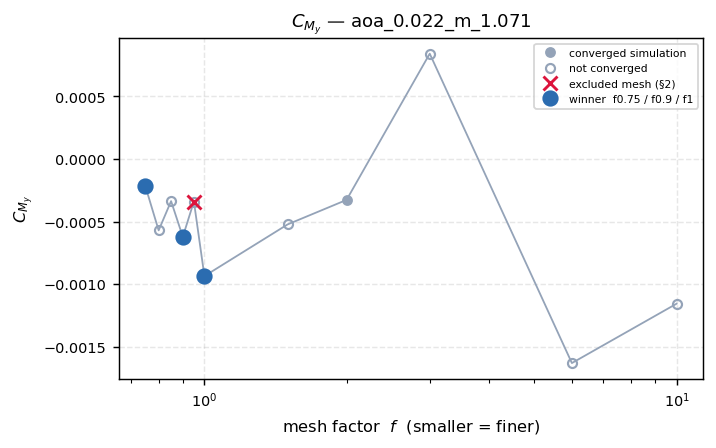
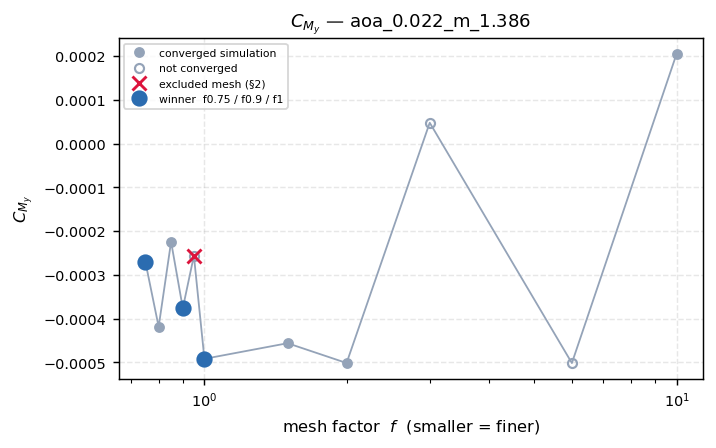
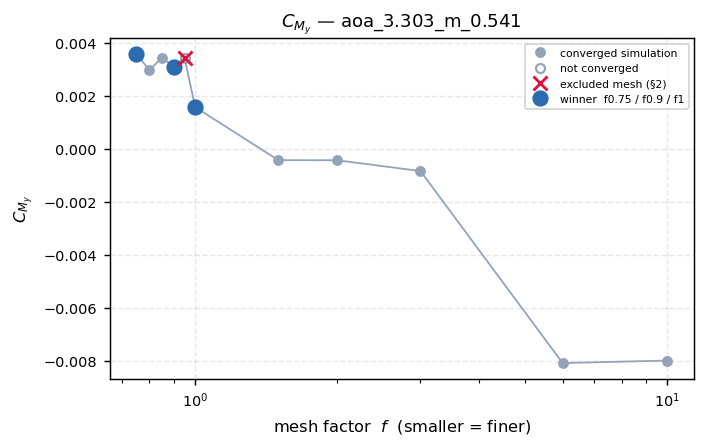

In [23]:
cols = []
for f in folders:
    per = []
    hit = ranked[f][ranked[f]['trio'] == winner].iloc[0]
    trio = winner.split(' / ')
    for var in VARS:
        col = f'{var}_mean_stage{STAGE}'
        clean = post[f].dropna(subset=[col])
        ok_mask = clean['case'].isin(converged[f])

        fig, ax = plt.subplots(figsize=(5.8, 3.4))
        ax.plot(clean['mesh'], clean[col], '-', color='#94a3b8', lw=1.0,
                zorder=2)
        ax.plot(clean.loc[ok_mask, 'mesh'], clean.loc[ok_mask, col], 'o',
                color='#94a3b8', markersize=5, zorder=2,
                label=T['l_converged_sim'])
        ax.plot(clean.loc[~ok_mask, 'mesh'], clean.loc[~ok_mask, col], 'o',
                markerfacecolor='none', markeredgecolor='#94a3b8',
                markersize=5, markeredgewidth=1.2, zorder=2,
                label=T['l_not_converged'])
        bad = clean[clean['case'].isin(EXCLUDED_CASES)]
        if len(bad):
            ax.plot(bad['mesh'], bad[col], 'x', color='crimson',
                    markersize=8, markeredgewidth=1.6, zorder=5,
                    label=T['l_excluded_mesh'])

        sel = clean[clean['case'].isin(trio)]
        ax.plot(sel['mesh'], sel[col], 'o', color='#2b6cb0', markersize=8,
                zorder=4, label=f"{T['l_winner']}  {winner}")
        if var == DECISION_VAR:
            ax.axhline(hit['f_extrapolated'], color='crimson', ls='--',
                       lw=1.2, zorder=1,
                       label=f"Richardson  (p = {hit['p']:.2f})")
            band = abs(hit['f_extrapolated']) * hit['GCI_21']
            ax.axhspan(hit['f_extrapolated'] - band,
                       hit['f_extrapolated'] + band,
                       color='crimson', alpha=0.12, zorder=0,
                       label=f"GCI = {hit['GCI_%']:.1f} %")
        ax.set(xscale='log', xlabel=T['x_factor'], ylabel=NICE[var])
        ax.set_title(f'{NICE[var]} — {f}')
        ax.legend(loc='best', fontsize=6)
        per.append(as_png(fig))
    cols.append(per)

grid(cols, folders, caption=T['c_curves'])

---

# 6. Cross-check on a surface field

Everything so far rests on an integral the solver itself computes. It remains to see
whether the choice holds when starting from an unrelated quantity: a reduction of the
wall $C_p$ field.

The same filters as §4 apply — converged simulations only, no `f0.95` — and the same
score.

In [24]:
field = {}
for f, db in databases.items():
    t = db.sets.reduce_cases(CP, stage=STAGE, id_group=str(GROUP),
                             how='rms', dropna=True)
    t = t[t['case'].isin(converged[f])]
    if len(t) < 3:
        continue
    g = db.stats.richardson(t, CP, h_col='mesh', triplets='all')
    g['trio'] = g['fine'] + ' / ' + g['medium'] + ' / ' + g['coarse']
    g['GCI_%'] = g['GCI_21'] * 100
    ok = g[g['converged'] & (g['r21'] > 1) & (g['r32'] > 1)
           & np.isfinite(g['asymptotic_ratio'])]
    field[f] = score_triplets(ok)

per_root = []
for f in folders:
    if f not in field or not len(field[f]):
        per_root.append(pd.DataFrame({T['notice']: [T['no_field_triplet']]}))
        continue
    t = field[f][['rank', 'trio', 'r21', 'r32', 'p', 'f1', 'f_extrapolated',
                  'GCI_%', 'asymptotic_ratio', 'score']].copy()
    t.columns = T['cols_field']
    per_root.append(fmt(t, 4))

tables(per_root, folders, cols=1, caption=T['c_field'])

In [25]:
rows = []
for f in folders:
    row = {T['db']: f, T['winner_s4']: winner}
    hit = ranked[f][ranked[f]['trio'] == winner]
    row[T['rank_with'].format(what=DECISION_VAR)] = (
        int(hit['rank'].iloc[0]) if len(hit) else np.nan)
    row[f'GCI {DECISION_VAR} [%]'] = (hit['GCI_%'].iloc[0] if len(hit)
                                      else np.nan)
    table = field.get(f)
    fh = (table[table['trio'] == winner]
          if table is not None and len(table) else None)
    row[T['rank_with'].format(what='RMS(Cp)')] = (
        int(fh['rank'].iloc[0]) if fh is not None and len(fh) else np.nan)
    row['GCI RMS(Cp) [%]'] = (fh['GCI_%'].iloc[0]
                              if fh is not None and len(fh) else np.nan)
    row[T['best_with_field']] = (table['trio'].iloc[0]
                                 if table is not None and len(table) else '—')
    rows.append(row)

wide_table(fmt(pd.DataFrame(rows), 4), T['t_crossmag'],
           caption=T['c_crossmag'])

database,winning triplet (§4),rank with CoefDrag,GCI CoefDrag [%],rank with RMS(Cp),GCI RMS(Cp) [%],best with RMS(Cp)
aoa_0.022_m_1.071,f0.75 / f0.9 / f1,2,27.49,,,—
aoa_0.022_m_1.386,f0.75 / f0.9 / f1,8,28.97,10,0.3606,f0.75 / f2 / f10
aoa_3.303_m_0.541,f0.75 / f0.9 / f1,30,10.73,48,69.53,f0.75 / f1.5 / f3


**The cross-check does not confirm the choice.** The winner sits mid-table when judged
by RMS($C_p$), and at the limiting condition there are no admissible triplets on that
quantity at all: the four converged meshes leave no combination that clears the filters.
Starting from $C_p$, the ranking would have pointed at different triplets.

This does **not** invalidate the §4 choice — the study was decided on $C_D$ for stated
reasons, and it remains the best-conditioned variable. What it says is that **the
optimal triplet depends on the quantity one wants to predict**, which is another way of
restating §4.2: outside the asymptotic range there is no single correct answer. If the
target of the computation were the pressure field rather than drag, this study would
have to be redone with $C_p$ as the decision variable.

---

# 7. Reading the results

In [26]:
hit = {f: ranked[f][ranked[f]['trio'] == winner].iloc[0] for f in folders}
gcis = [float(hit[f]['GCI_%']) for f in folders]
ps = [float(hit[f]['p']) for f in folders]
limiting = min(folders, key=lambda f: len(converged[f]))

display(HTML(
    '<div style="border-left:4px solid #2b6cb0;padding:10px 16px;'
    'margin:6px 0 18px 0;background:#f5f8fc;border-radius:0 4px 4px 0;">'
    '<div style="font-size:1.05em;font-weight:600;margin-bottom:6px;">'
    + T['headline'] + '</div>'
    + T['headline_body'].format(
        winner=winner, mesh=fine_mesh, var=DECISION_VAR,
        gmin=f'{min(gcis):.1f}', gmax=f'{max(gcis):.1f}',
        pmin=f'{min(ps):.2f}', pmax=f'{max(ps):.2f}')
    + '</div>'))

### What the study does establish

**One triplet works at all three flight conditions**, selected by an explicit and
reproducible criterion: a score on Richardson's own hypotheses — never on the GCI, which
is the quantity being measured — followed by a *minimax* consensus across the three
rankings. Changing the §4.2 weights changes the ordering, but the procedure is written
down and auditable.

**The convergence filter is indispensable, though not for the reason expected.** It
discards triplets built on simulations with residuals of $10^{-1}$, which are
indefensible however attractive their GCI. But it does **not** explain the scatter:
where nearly every simulation converges, the distribution is the same before and after
(§4.2). The threshold itself, on the other hand, is immaterial: between $10^{-4}$ and
$10^{-3}$ the surviving mesh set is identical.

### What the study does not establish

**It does not demonstrate that the solution is mesh-converged.** The winner's observed
orders fall below the nominal second order of the scheme, and its GCI runs to several
tens of per cent at two of the three conditions. The recommended mesh is the best these
data support; it is not a mesh with small uncertainty.

**The study is limited by one flight condition.** Of the eleven simulations per
condition, the most restrictive leaves only four converged, and the winner necessarily
comes from the handful of combinations those four allow. The other two conditions offer
many more candidates that cannot be used, because the triplet has to hold at all three.

**The winner is weakly refined.** Its ratios are $r_{21} = 1.2$ and $r_{32} = 1.11$, far
from the desirable $r = 2$. That is not a choice of the method but of what is available:
the converged meshes common to all three conditions sit very close together.

**The choice depends on the quantity to be predicted.** §6 redoes the ranking from
RMS($C_p$) and points at different triplets. This is consistent with everything above:
outside the asymptotic range there is no single correct triplet, only the best one for
the quantity being optimised.

In [27]:
rows = []
for f in folders:
    total = len(post[f])
    excluded_here = len(set(EXCLUDED_CASES) & set(post[f]['case']))
    rows.append({
        T['db']: f,
        T['n_sims']: total,
        T['n_excluded']: excluded_here,
        T['n_usable']: len(converged[f]),
        T['n_unconverged']: total - excluded_here - len(converged[f]),
        T['n_admissible']: len(ranked[f]),
        T['winner_rank']: int(hit[f]['rank']),
    })
wide_table(pd.DataFrame(rows), T['t_budget'],
           caption=T['c_budget'].format(root=limiting))

database,simulations,excluded (§2),converged and usable,not converged,admissible triplets,winner's rank
aoa_0.022_m_1.071,11,1,4,6,2,2
aoa_0.022_m_1.386,11,1,8,2,21,8
aoa_3.303_m_0.541,11,1,10,0,61,30


### Recommendation

1. **Use the recommended mesh of §4.5 for production**, reporting its $C_D$ together
   with the uncertainty band from that same table. It is the fine mesh of the winning
   triplet and the only one whose uncertainty is quantified.
2. **Drive the remaining simulations at the limiting condition to convergence.** This is
   by far the highest-return action: it requires no new mesh, only further iteration of
   runs that already exist, and it would multiply the available triplets.
3. **Regenerate `f0.95`**, which currently adds no wall refinement (§2).
4. **Find out why the observed orders come out low** before refining further. The usual
   causes are insufficient iterative convergence, mesh topology changes between levels,
   or a solution that is not genuinely steady. Tightening the mesh fixes none of them.
5. For future studies, **generate the family in geometric progression** ($f$, $2f$,
   $4f$) and converge all three levels hard: three well-spaced, well-converged runs give
   a more trustworthy GCI than eleven closely spaced and half-converged ones.

---

<div style="font-size:0.84em;color:#4a5568;">
Report generated automatically by <code>build_gci_report.py</code> from
<code>coda_single_GCI_en.ipynb</code>, using FotR (FRODO · <code>CODA_SINGLE</code>
format). Convergence computations come from
<code>CODASingleStats.richardson</code>; the per-mesh reductions from
<code>CODASingleSets.reduce_cases</code>; the solver convergence verdict from
<code>CODAResiduals.update_converged_state</code>.
</div>